In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib_inline
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import special
from scipy.optimize import Bounds, NonlinearConstraint

from FFTOptionPricing import OptionPricingFFT, Calibration
from run_differential_evol import run_differential_evolution

In [3]:
%matplotlib inline

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
%config InlineBackend.figure_formats = ['retina']

## 1. Importing and pre-processing of data

In [4]:
filepaths_options = {
    'ASML': './Option Data/0#ASME*.EX.xlsx',
    'HRMS': './Option Data/0#HMIE*.EX.xlsx',
    'ITX': './Option Data/0#IXDE*.EX.xlsx',
    'LVMH': './Option Data/0#MOHE*.EX.xlsx',
    'OREP': './Option Data/0#LORE*.EX.xlsx',
    'PRX': './Option Data/0#PRXE*.EX.xlsx',
    'SAPG': './Option Data/0#SAPE*.EX.xlsx',
    'SCHN': './Option Data/0#SNDE*.EX.xlsx',
    'SIEE': './Option Data/0#SIEE*.EX.xlsx',
    'TOTF': './Option Data/0#TOTE*.EX.xlsx',
}

tickers = [key for key, _ in filepaths_options.items()]

stock_prices = []
option_dfs = {}

for key, value in filepaths_options.items():
    df = pd.read_excel(value)

    df['time_to_maturity_years'] = pd.to_numeric(df['time_to_maturity_years'], errors='coerce')
    df['strike'] = pd.to_numeric(df['strike'], errors='coerce')
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['vega'] = pd.to_numeric(df['vega'], errors='coerce').dropna()

    df = df[df['vega'] != 0]
    df = df[df['strike'] > 1]
    df = df[(df['time_to_maturity_years'] < 1.0) & (df['time_to_maturity_years'] > 0.02)]

    option_dfs[key] = df
    stock_prices.append(df['S0'].unique().item())

## 2. Calibration

### 2.1 Differential evolution

In [5]:
r = 3.6 * 1e-2 #SOFR risk-free rate per 2026-05-10
CarrMadan_params = [0.25, 2**8, 1.5]
VG_params_init = np.array([0.25, -0.15, 0.001]) #sigma, theta, nu

alpha = CarrMadan_params[2]

def martingale_margin(VG_params):
    sigma, theta, nu = VG_params
    return 1 - theta*nu - 0.5*nu*sigma**2

def alpha_margin(VG_params):
    sigma, theta, nu = VG_params
    return np.sqrt(theta**2/sigma**4 + 2/(nu*sigma**2)) - theta/sigma**2 - 1

In [6]:
strategy = 'rand2bin'

#sigma, theta, nu
lower = np.array([0.05, -5.0, 0.0001], dtype=float)
upper = np.array([0.6, -0.001, 0.1], dtype=float)
bounds = Bounds(lower, upper)

MG_constraint = NonlinearConstraint(martingale_margin, lb=1e-6, ub=np.inf)
alpha_constraint = NonlinearConstraint(alpha_margin, lb=alpha+1e-6, ub=np.inf)

constraint = (MG_constraint, alpha_constraint)

In [7]:
results_FFT = []
calibrations_FFT = []

for i, ticker in enumerate(tickers):
    print(f'------------------------------------------------------------------ Processing stock: {ticker} ------------------------------------------------------------------')
    print()

    option_df = option_dfs[ticker]
    S0 = stock_prices[i]

    print(f'S0 = {S0}')
    print(f'Length of data: {len(option_df)}')
    print()

    calibration_FFT = Calibration(
        df=option_df, 
        S0=S0,
        r=r,
        VG_params_init=VG_params_init,
        CarrMadan_params=CarrMadan_params
    )

    result_FFT = run_differential_evolution(
        class_=calibration_FFT,
        args=(),
        bounds=bounds,
        strategy=strategy,
        x0=VG_params_init,
        constraint=constraint
    )

    calibrations_FFT.append(calibration_FFT)
    results_FFT.append(result_FFT)

    print()
    print(f'Optimal parameters [sigma, theta, nu]: {result_FFT.x}')
    print(f'Objective value: {result_FFT.fun}')
    print()

------------------------------------------------------------------ Processing stock: ASML ------------------------------------------------------------------

S0 = 1319.4
Length of data: 220

differential_evolution step 1: f(x)= 0.33091610847158537
[DE] conv=0.000 best_x≈[ 0.40382319 -0.08541927  0.0497572 ]
differential_evolution step 2: f(x)= 0.33091610847158537
[DE] conv=0.000 best_x≈[ 0.40382319 -0.08541927  0.0497572 ]
differential_evolution step 3: f(x)= 0.33091610847158537
[DE] conv=0.000 best_x≈[ 0.40382319 -0.08541927  0.0497572 ]
differential_evolution step 4: f(x)= 0.33091610847158537
[DE] conv=0.000 best_x≈[ 0.40382319 -0.08541927  0.0497572 ]
differential_evolution step 5: f(x)= 0.33091610847158537
[DE] conv=0.000 best_x≈[ 0.40382319 -0.08541927  0.0497572 ]
differential_evolution step 6: f(x)= 0.33091610847158537
[DE] conv=0.000 best_x≈[ 0.40382319 -0.08541927  0.0497572 ]
differential_evolution step 7: f(x)= 0.33091610847158537
[DE] conv=0.000 best_x≈[ 0.40382319 -0.08541

### 2.2 Model evaluation

In [8]:
def interpolate_fft_prices(K_grid, C_grid, strikes):
    prices = np.full(len(strikes), np.nan, dtype=float)

    in_range = (strikes >= K_grid[0]) & (strikes <= K_grid[-1])
    if not np.any(in_range):
        return prices

    strikes_use = strikes[in_range]
    left_idx = np.searchsorted(K_grid, strikes_use, side='right') - 1
    left_idx = np.clip(left_idx, 0, len(K_grid) - 2)

    K_left = K_grid[left_idx]
    K_right = K_grid[left_idx + 1]
    weight = (strikes_use - K_left) / (K_right - K_left)

    C_left = C_grid[left_idx]
    C_right = C_grid[left_idx + 1]
    prices[in_range] = (1.0 - weight) * C_left + weight * C_right

    return prices

def model_prices_FFT(df, S0, r, VG_params, CarrMadan_params):
    df = df.copy()
    df['FFT_price'] = np.nan
    df['FFT_error'] = np.nan
    df['FFT_rel_error'] = np.nan

    maturities = np.sort(df['time_to_maturity_years'].dropna().unique())

    for T in maturities:
        pricer = OptionPricingFFT(S0=S0, r=r, T=T, VG_params=VG_params, CarrMadan_params=CarrMadan_params)

        K_grid, C_grid = pricer.price_options_FFT()

        rows = np.isclose(df['time_to_maturity_years'].to_numpy(), T, atol=1e-10, rtol=0.0)
        strikes = df.loc[rows, 'strike'].to_numpy(dtype=float)
        market_prices = df.loc[rows, 'price'].to_numpy(dtype=float)

        model_prices = interpolate_fft_prices(K_grid, C_grid, strikes)

        df.loc[rows, 'FFT_price'] = model_prices
        df.loc[rows, 'FFT_error'] = model_prices - market_prices
        df.loc[rows, 'FFT_rel_error'] = (model_prices - market_prices) / market_prices

    return df

def error_metrics(df, price_col='FFT_price', market_col='price'):
    y_true = pd.to_numeric(df[market_col], errors='coerce').to_numpy(dtype=float)
    y_pred = pd.to_numeric(df[price_col], errors='coerce').to_numpy(dtype=float)

    ok = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0.0)
    if not np.any(ok):
        return {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'n_obs': 0}

    err = y_pred[ok] - y_true[ok]
    rel_err = err / y_true[ok]

    return {
        'MAE': float(np.mean(np.abs(err))),
        'RMSE': float(np.sqrt(np.mean(err**2))),
        'MAPE': float(100.0 * np.mean(np.abs(rel_err))),
        'n_obs': int(np.sum(ok)),
    }

In [9]:
errors = []
dfs = []

for i, ticker in enumerate(tickers):
    S0 = stock_prices[i]
    VG_params = results_FFT[i].x

    df = model_prices_FFT(option_dfs[ticker], S0, r, VG_params, CarrMadan_params)
    df.insert(0, 'TKR', ticker)

    dfs.append(df)
    errors.append({'TKR': ticker, **error_metrics(df)})

errors_df = pd.DataFrame(errors)
print(errors_df)

    TKR        MAE       RMSE       MAPE  n_obs
0  ASML   9.457081  12.109967   3.318290    220
1  HRMS  19.044128  24.987051  15.056485    196
2   ITX   0.766842   0.915625  17.913176    158
3  LVMH   2.557813   3.429703  10.960734    186
4  OREP   2.316568   2.925414  13.912430    174
5   PRX   0.501064   0.635772   8.535935    152
6  SAPG   3.001465   3.729209  14.772025    182
7  SCHN   0.536620   0.655096   6.358789    179
8  SIEE   1.442134   1.688363   5.250790    179
9  TOTF   0.868808   1.170880  11.298722    195


In [10]:
rows = []

for ticker, S0, result in zip(tickers, stock_prices, results_FFT):
    sigma, theta, nu = result.x

    A = np.sqrt((0.5*theta*nu)**2 + 0.5*nu*sigma**2)

    C = 1/nu
    G = 1/(A - 0.5*theta*nu)
    M = 1/(A + 0.5*theta*nu)

    rows.append({
        'TKR': ticker,
        'S0': S0,
        'r': r,
        'C': C,
        'G': G,
        'M': M,
        'sigma': sigma,
        'theta': theta,
        'nu': nu,
        'objective_value': result.fun,
        'success': result.success,
        'message': str(result.message),
        'nit': getattr(result, 'nit', np.nan),
        'nfev': getattr(result, 'nfev', np.nan),
    })

df_FFT = pd.DataFrame(rows)
print(df_FFT)

    TKR       S0      r           C          G            M     sigma  \
0  ASML  1319.40  0.036   35.552707  21.111231    21.125317  0.399294   
1  HRMS  1661.00  0.036   80.875976  41.120758    41.144894  0.309198   
2   ITX    51.34  0.036   47.401497  27.530204    83.049679  0.203628   
3  LVMH   472.70  0.036   10.000063  14.204227    14.224724  0.314619   
4  OREP   363.00  0.036   26.510965  21.871892    43.124724  0.237094   
5   PRX    41.01  0.036   19.877356  16.705247    16.823077  0.376110   
6  SAPG   146.20  0.036   27.527768  18.799312    18.829246  0.394378   
7  SCHN   272.60  0.036  148.677592  40.634481  1223.445847  0.077339   
8  SIEE   264.95  0.036  105.697075  47.294426    47.358739  0.307214   
9  TOTF    75.80  0.036   19.011973  25.127325    25.160588  0.245242   

      theta        nu  objective_value  success  \
0 -0.001123  0.028127         0.300157     True   
1 -0.001154  0.012365         6.848920     True   
2 -1.151039  0.021096        11.176178     

### 2.3 Plots

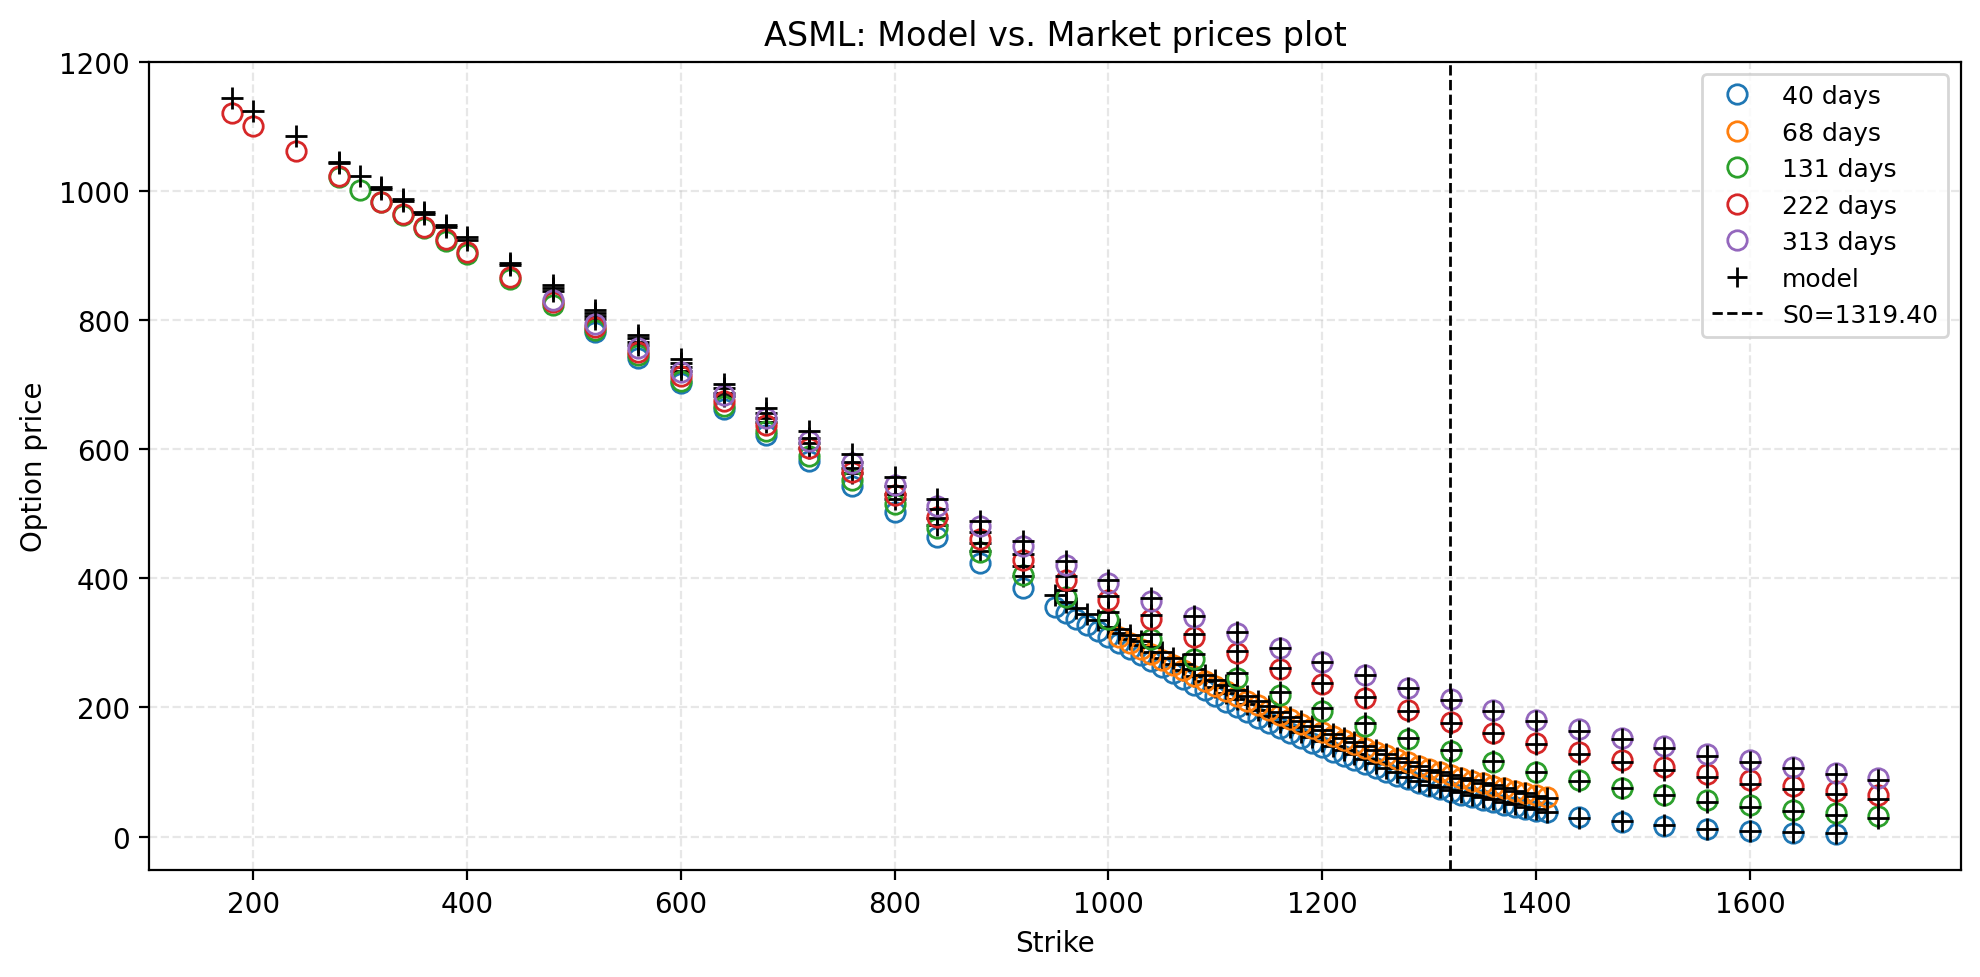

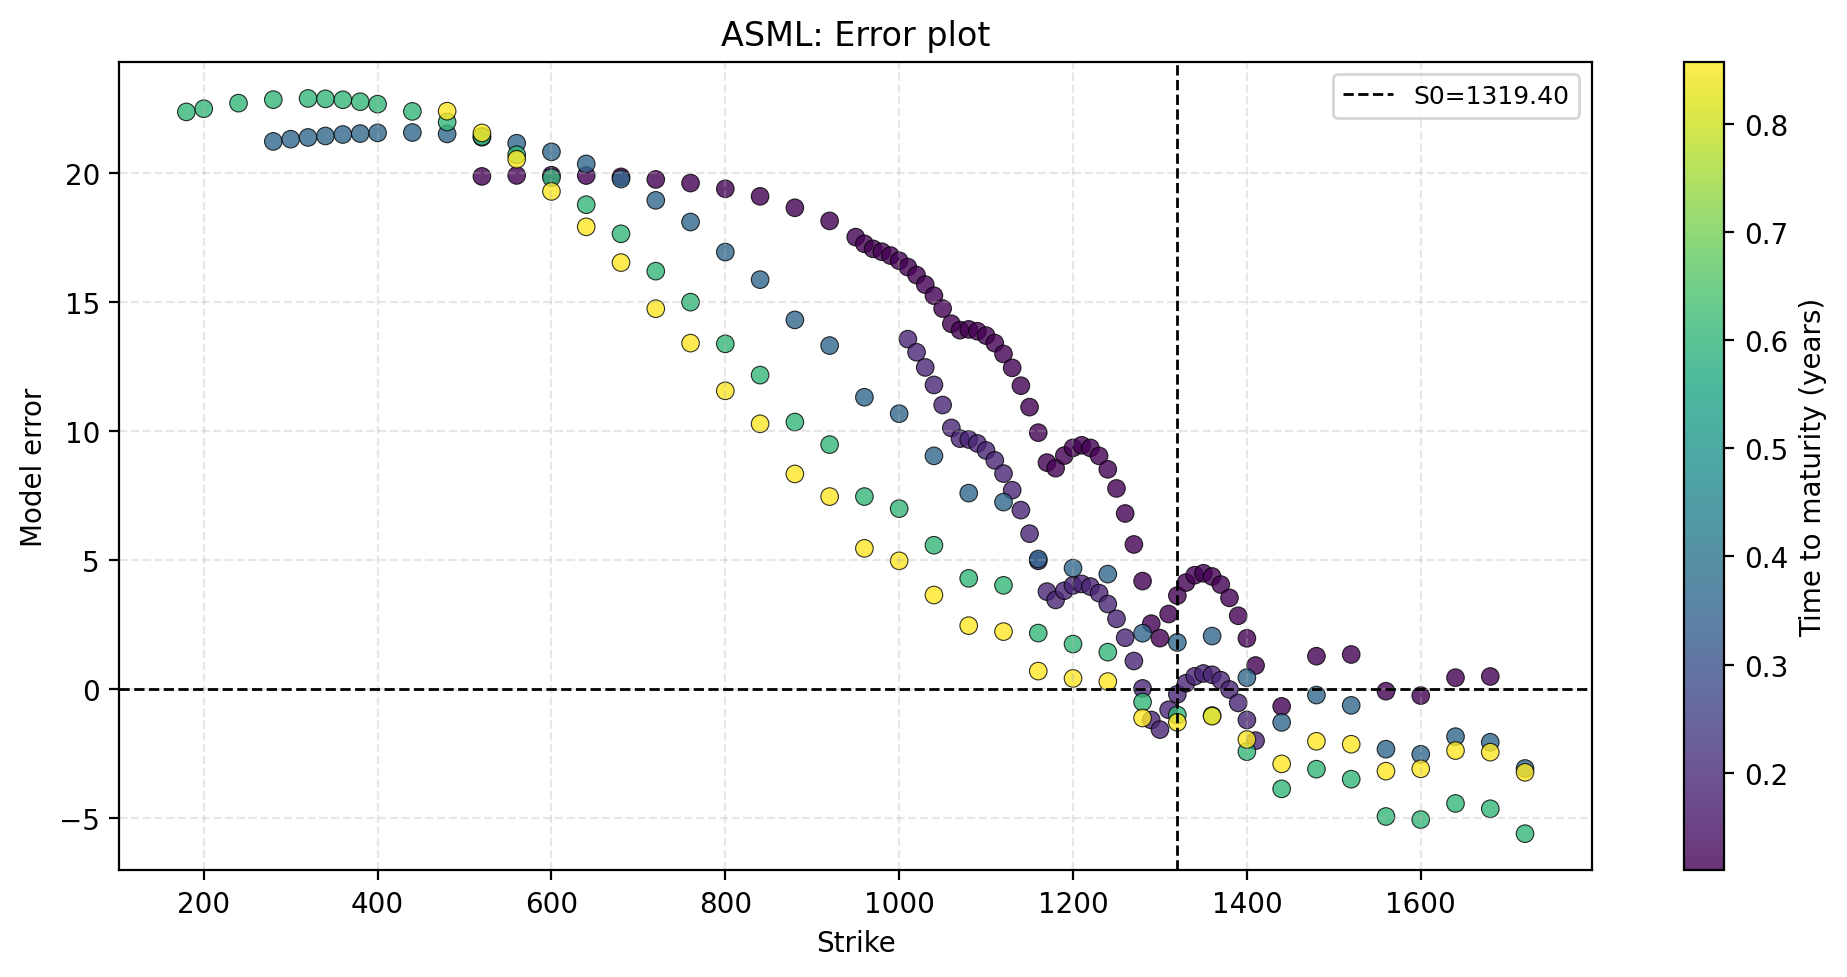

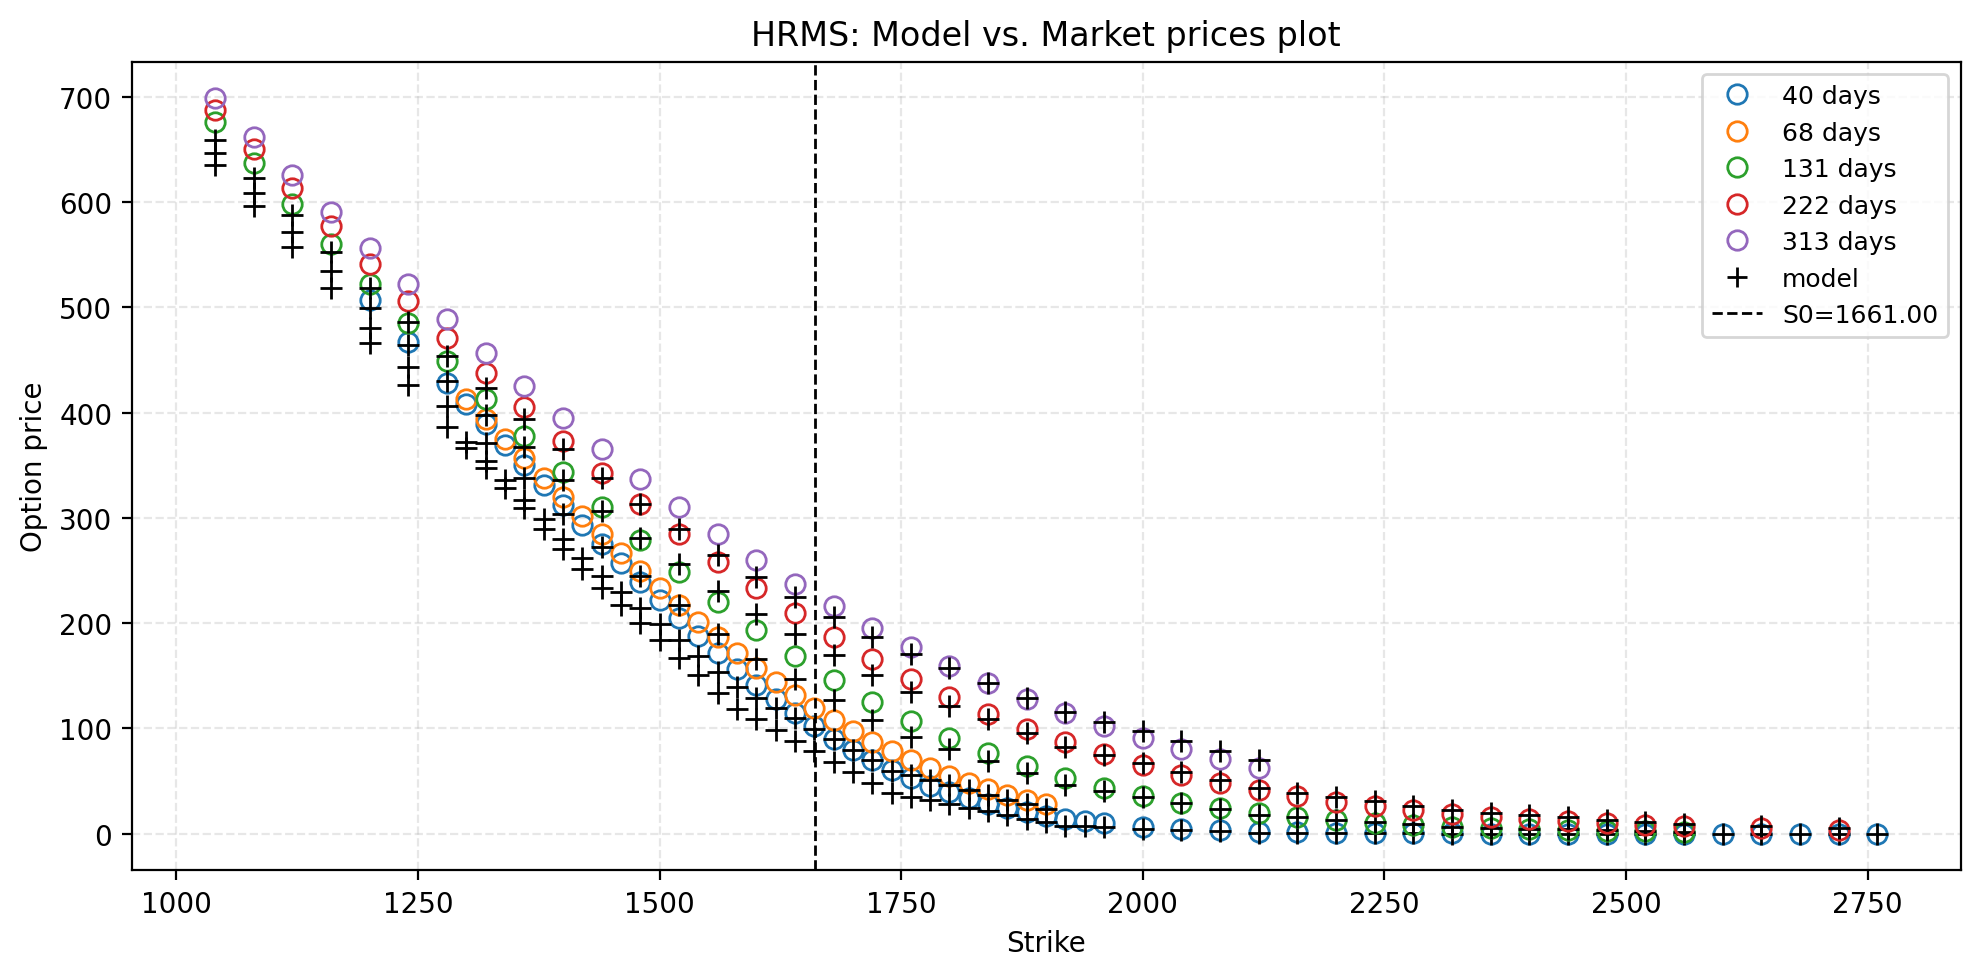

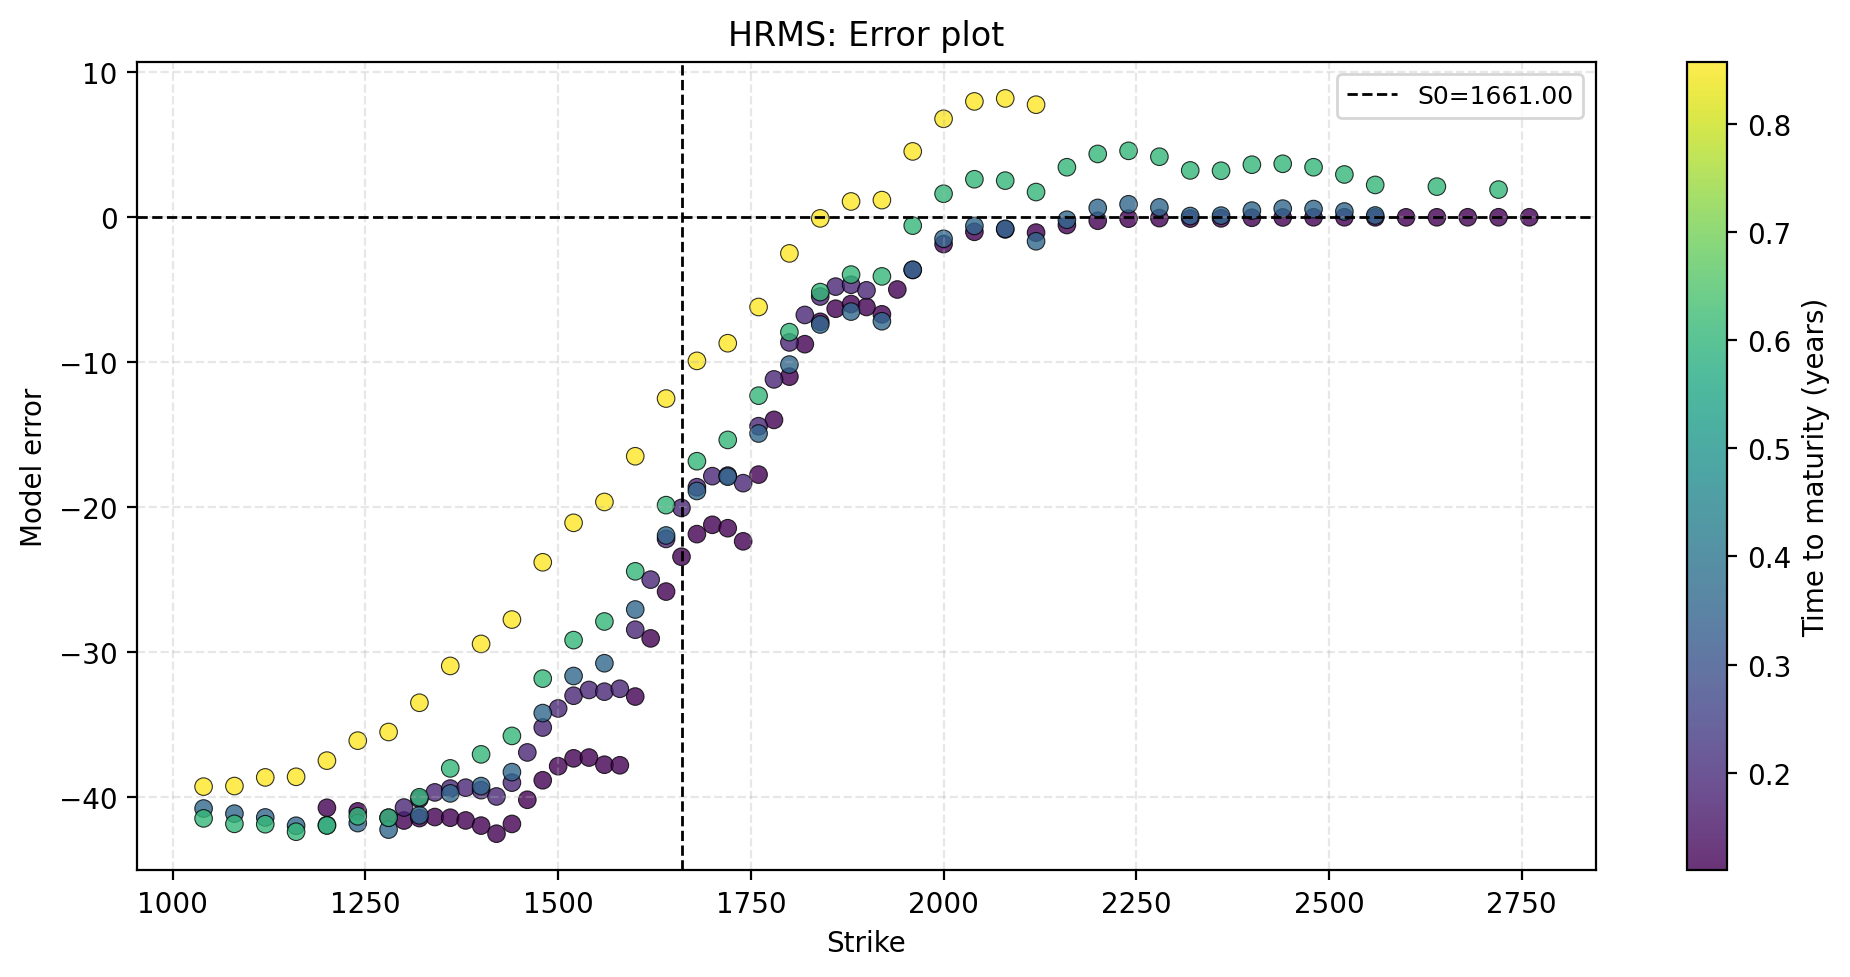

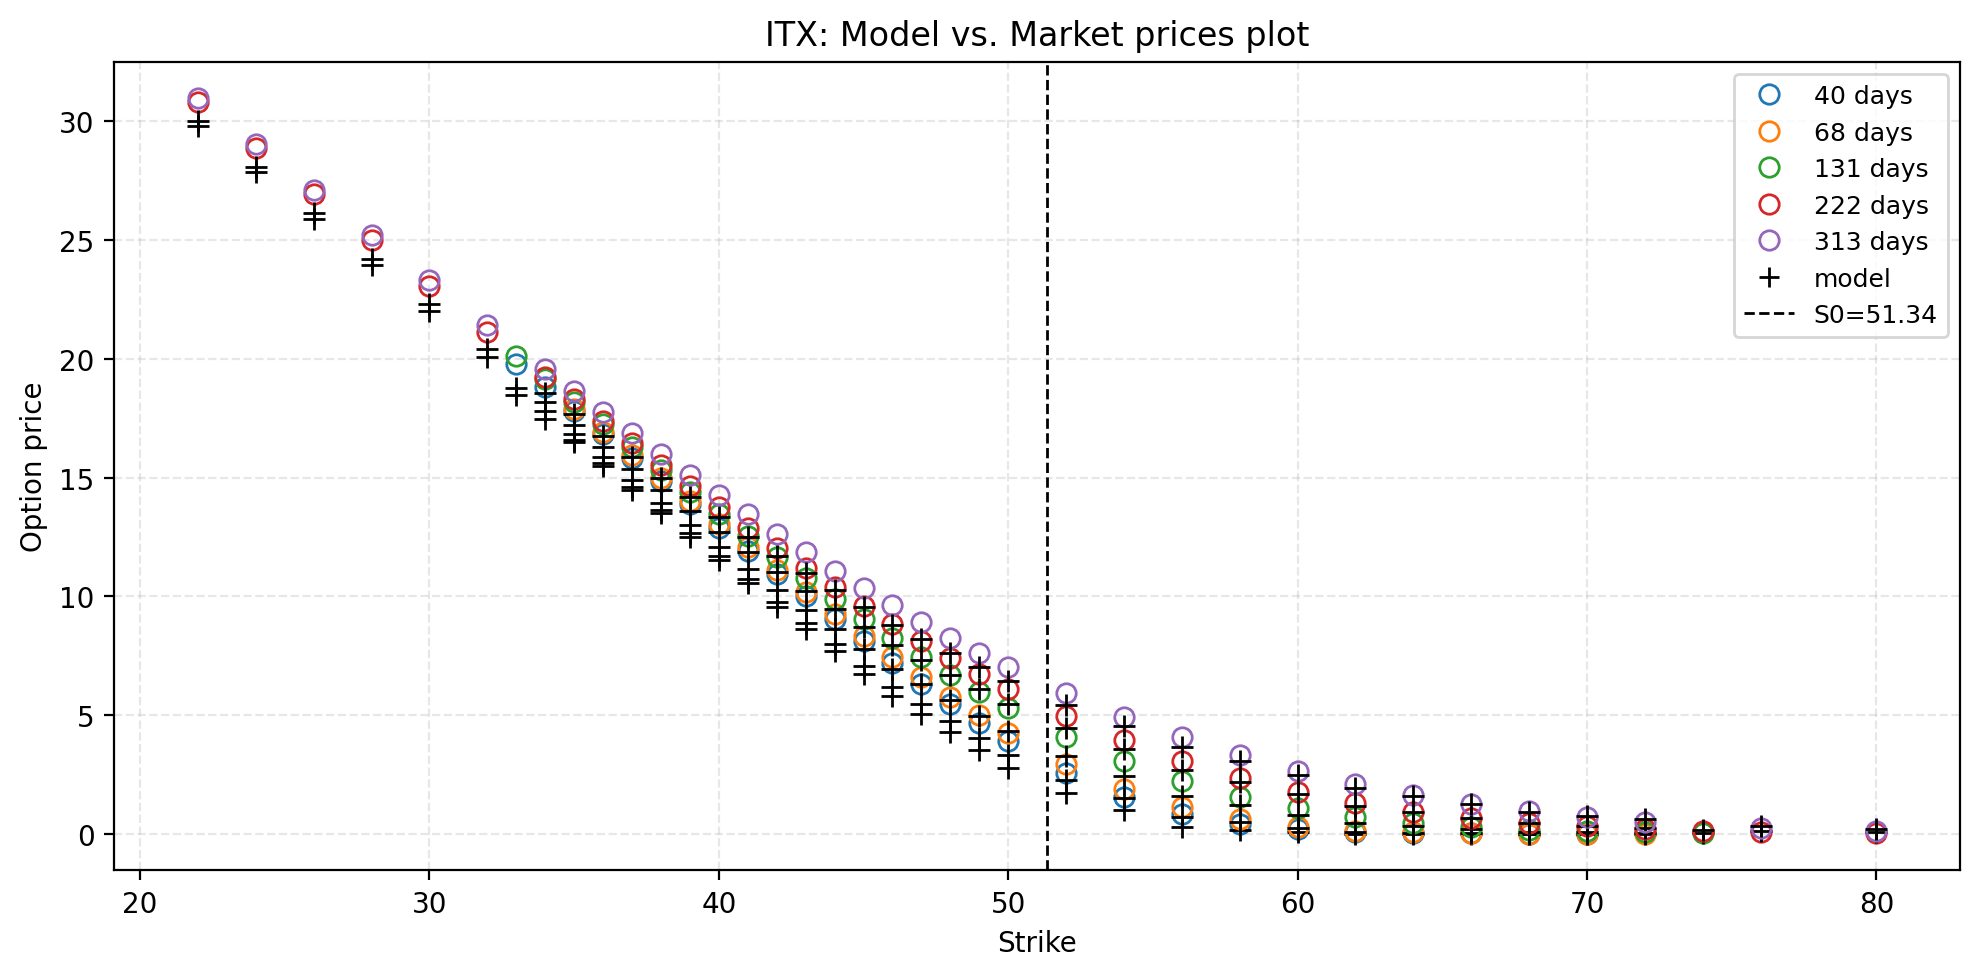

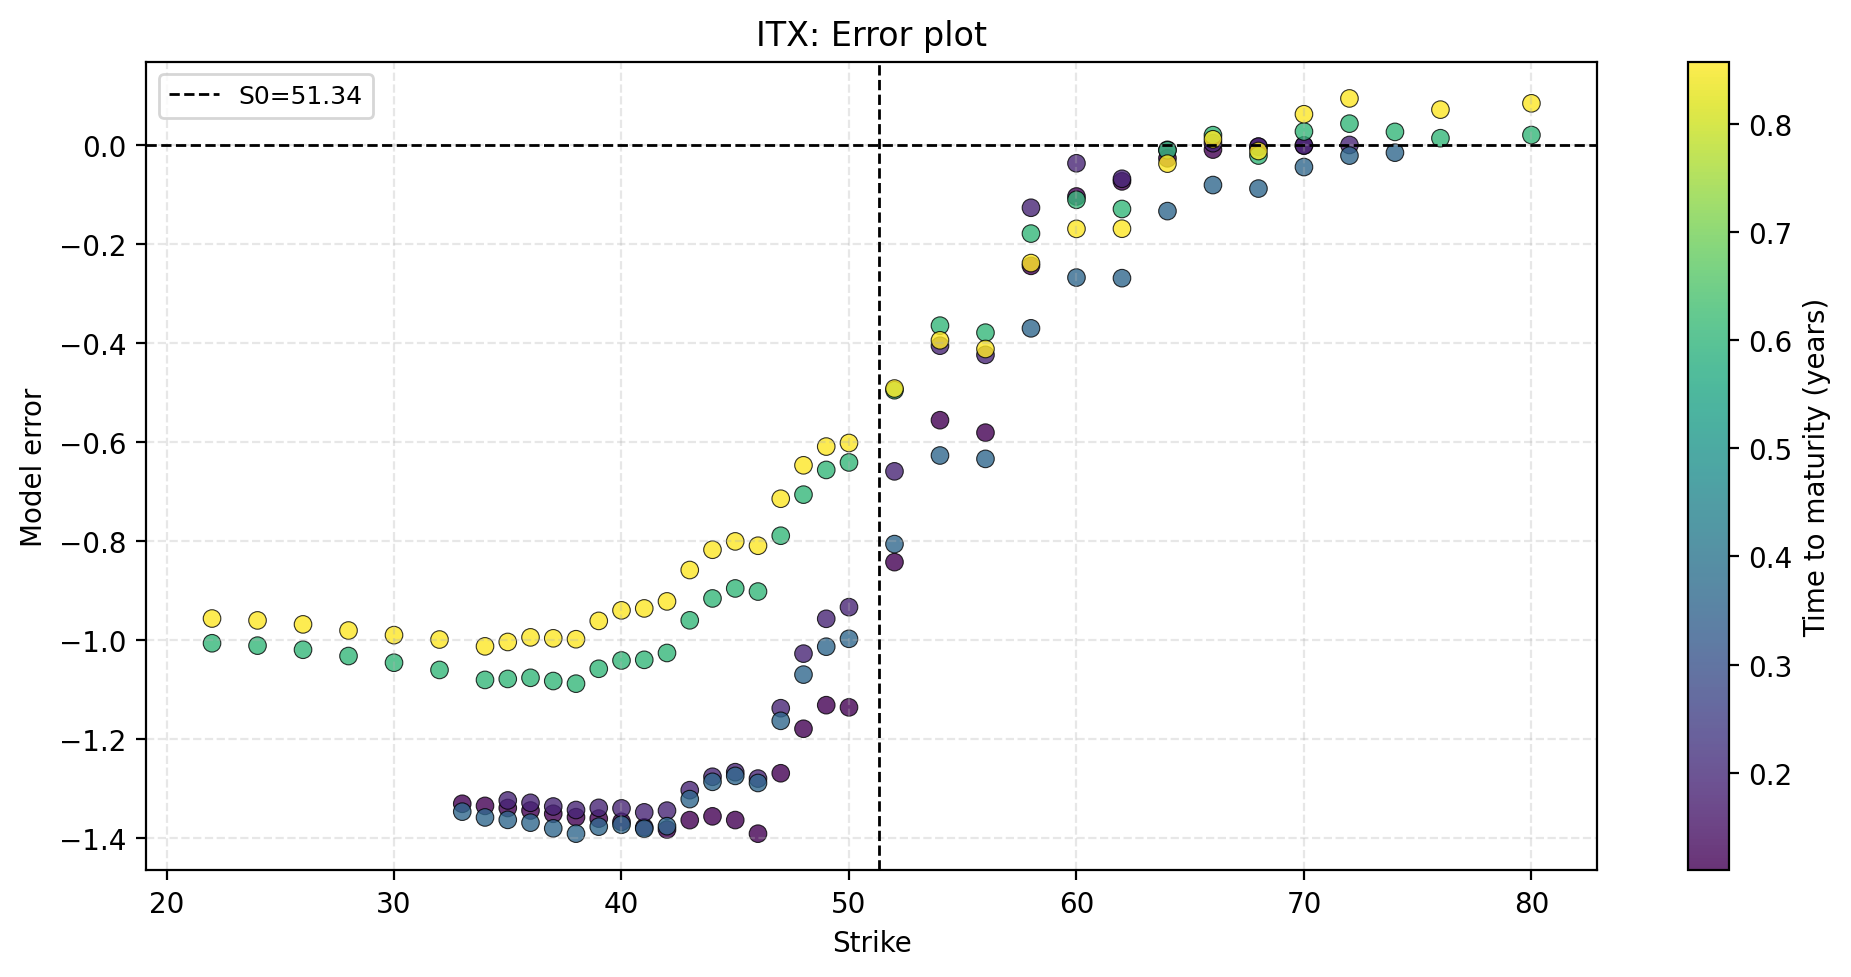

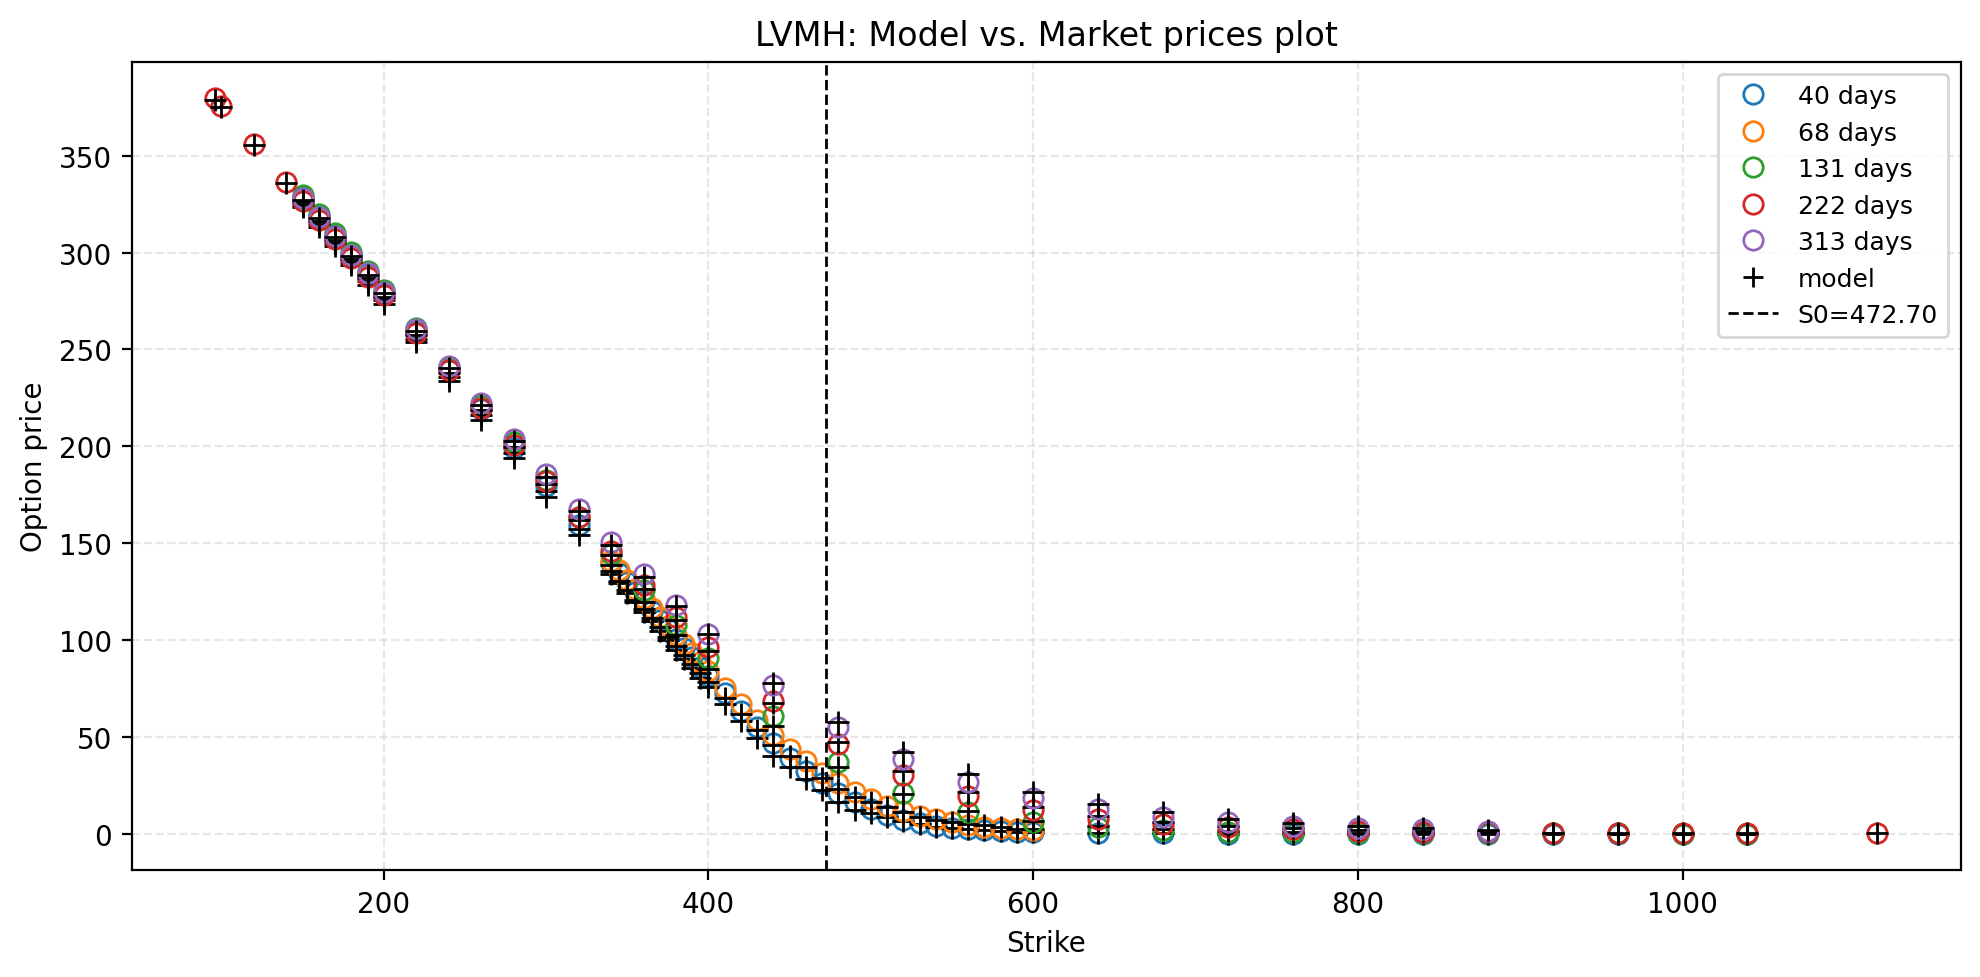

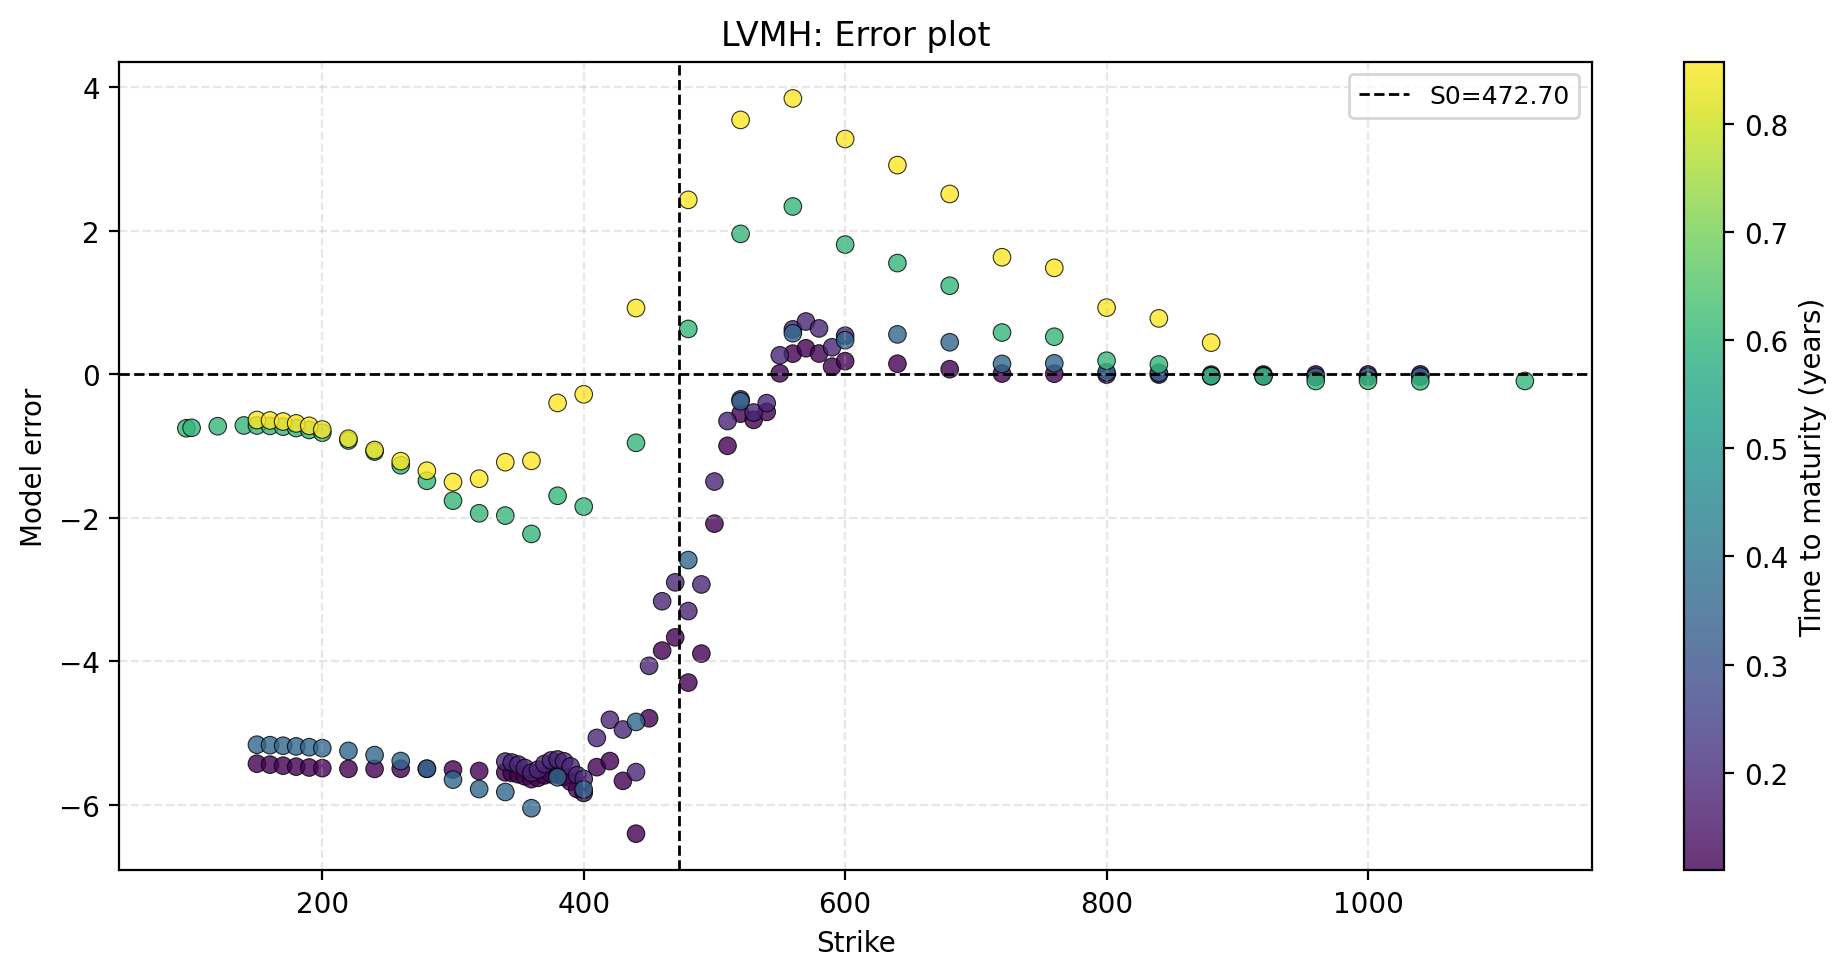

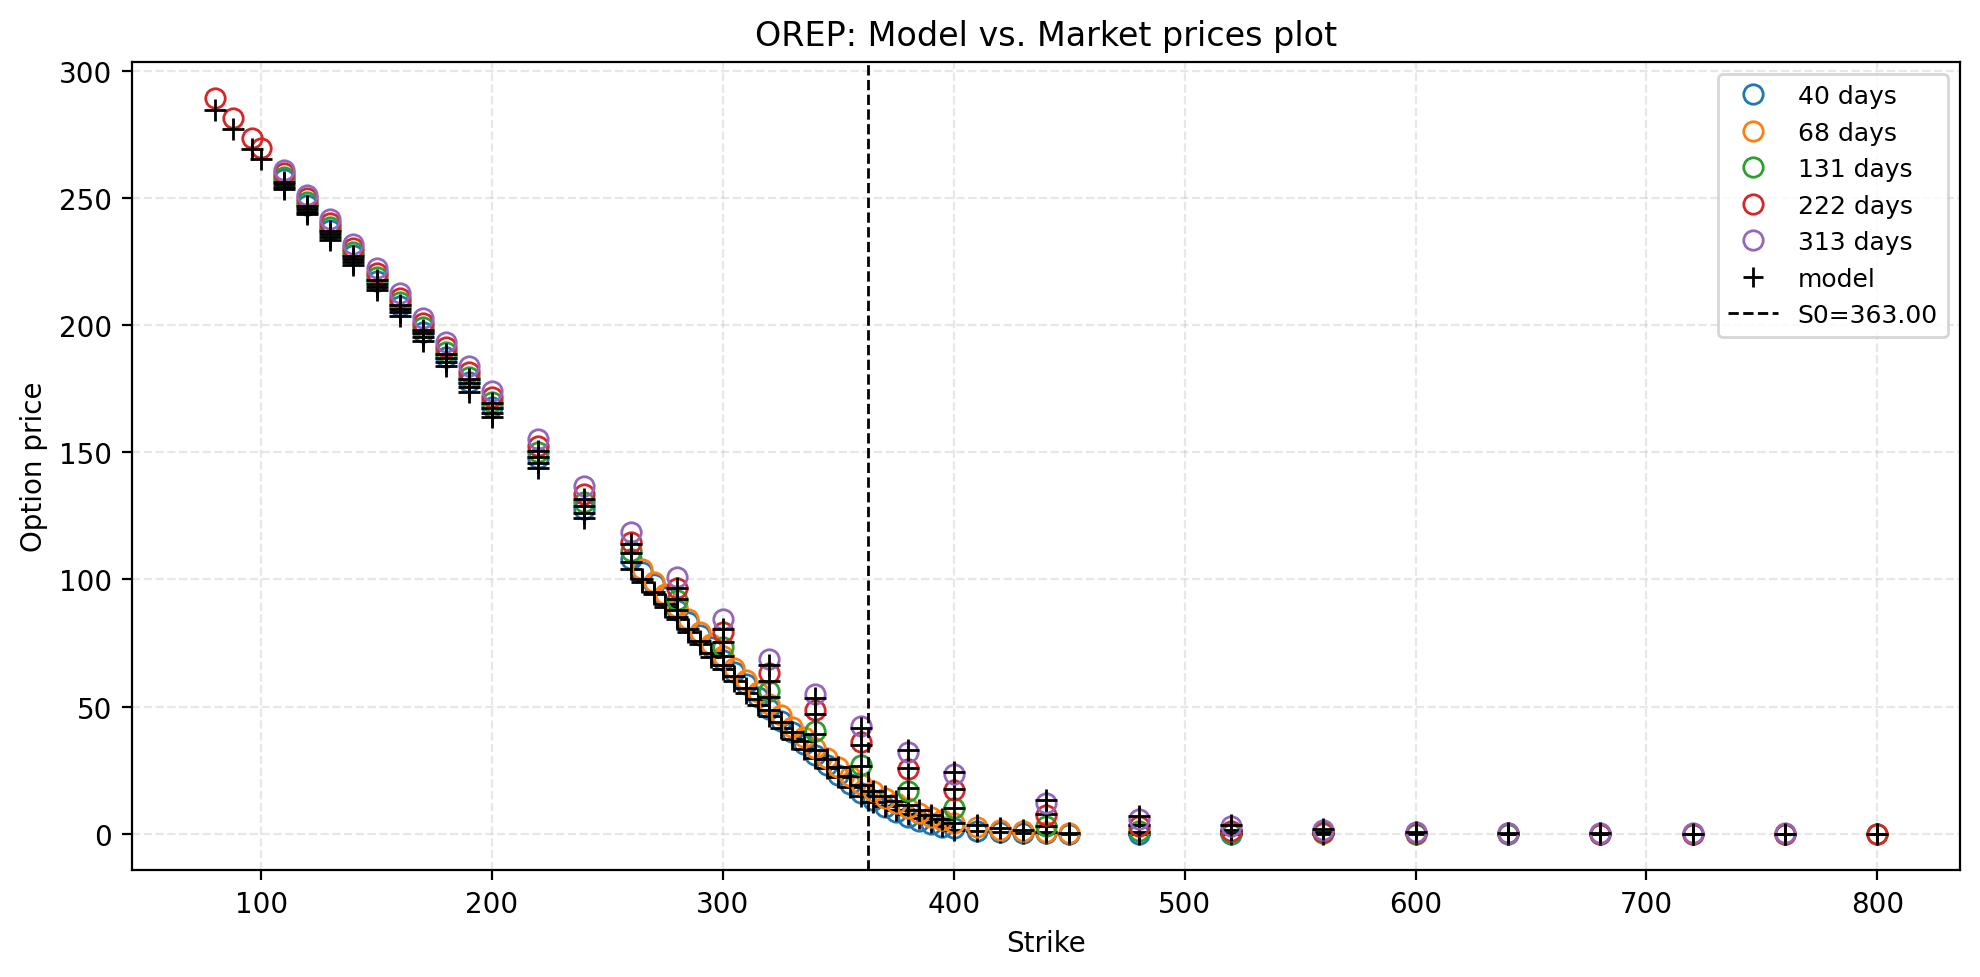

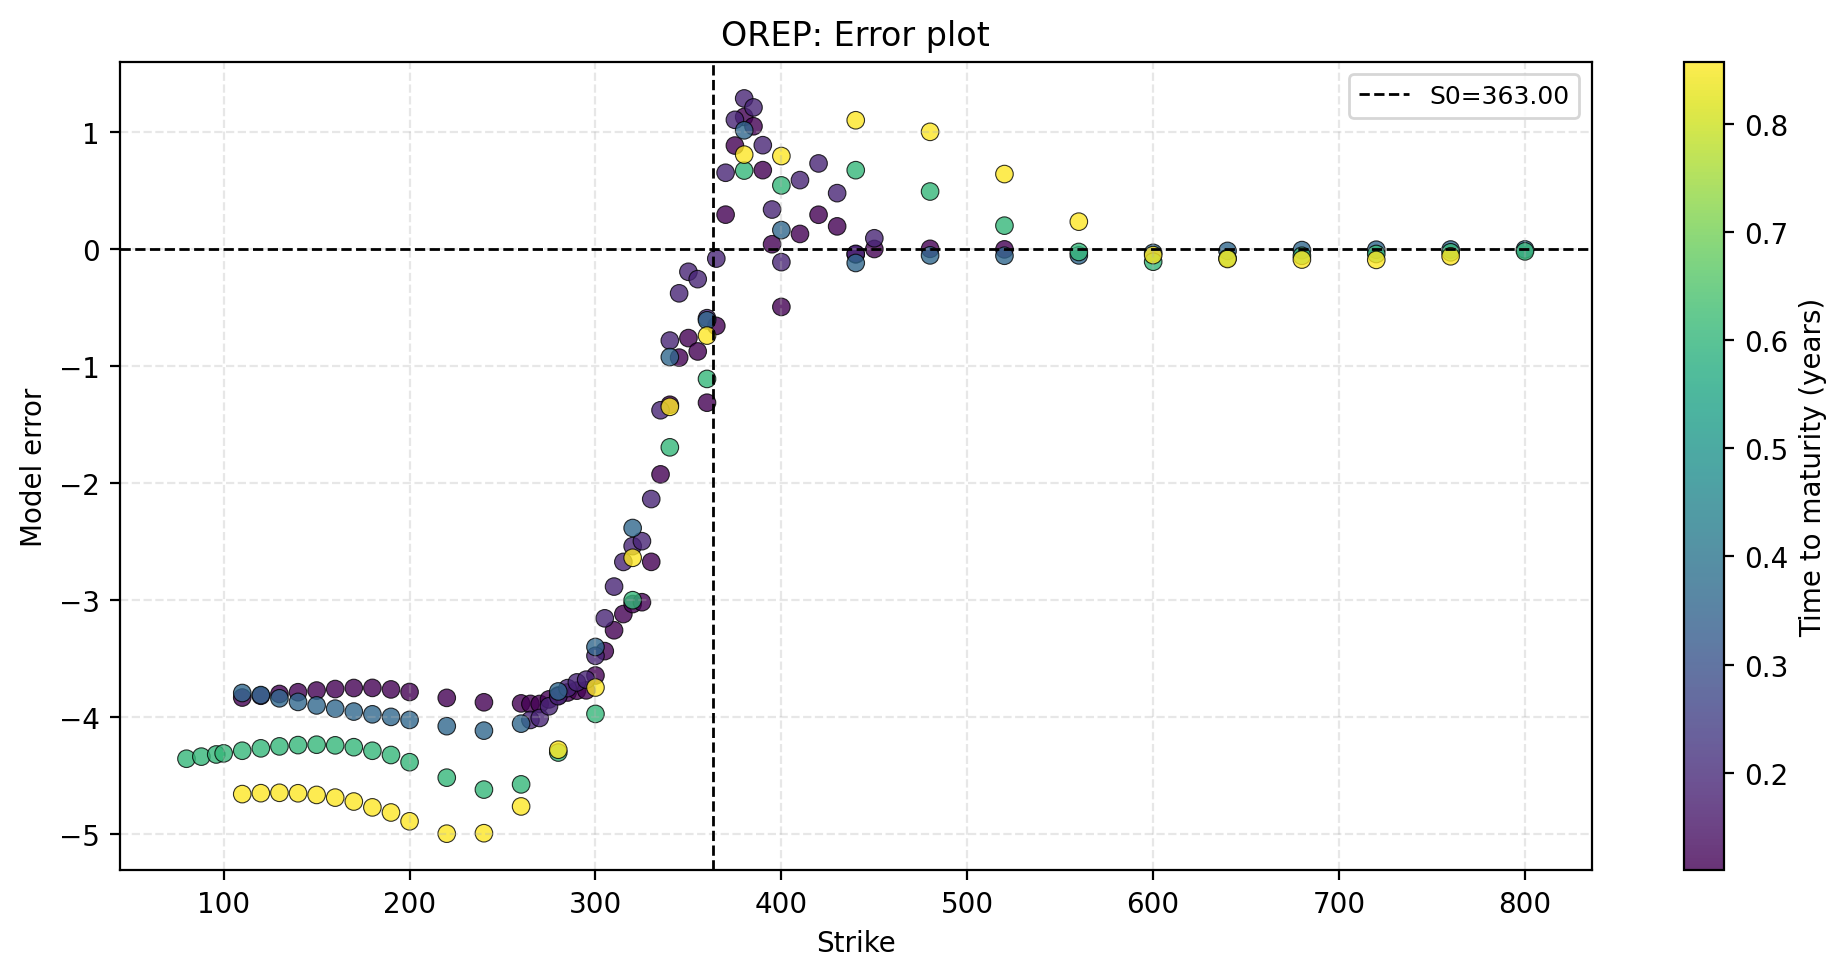

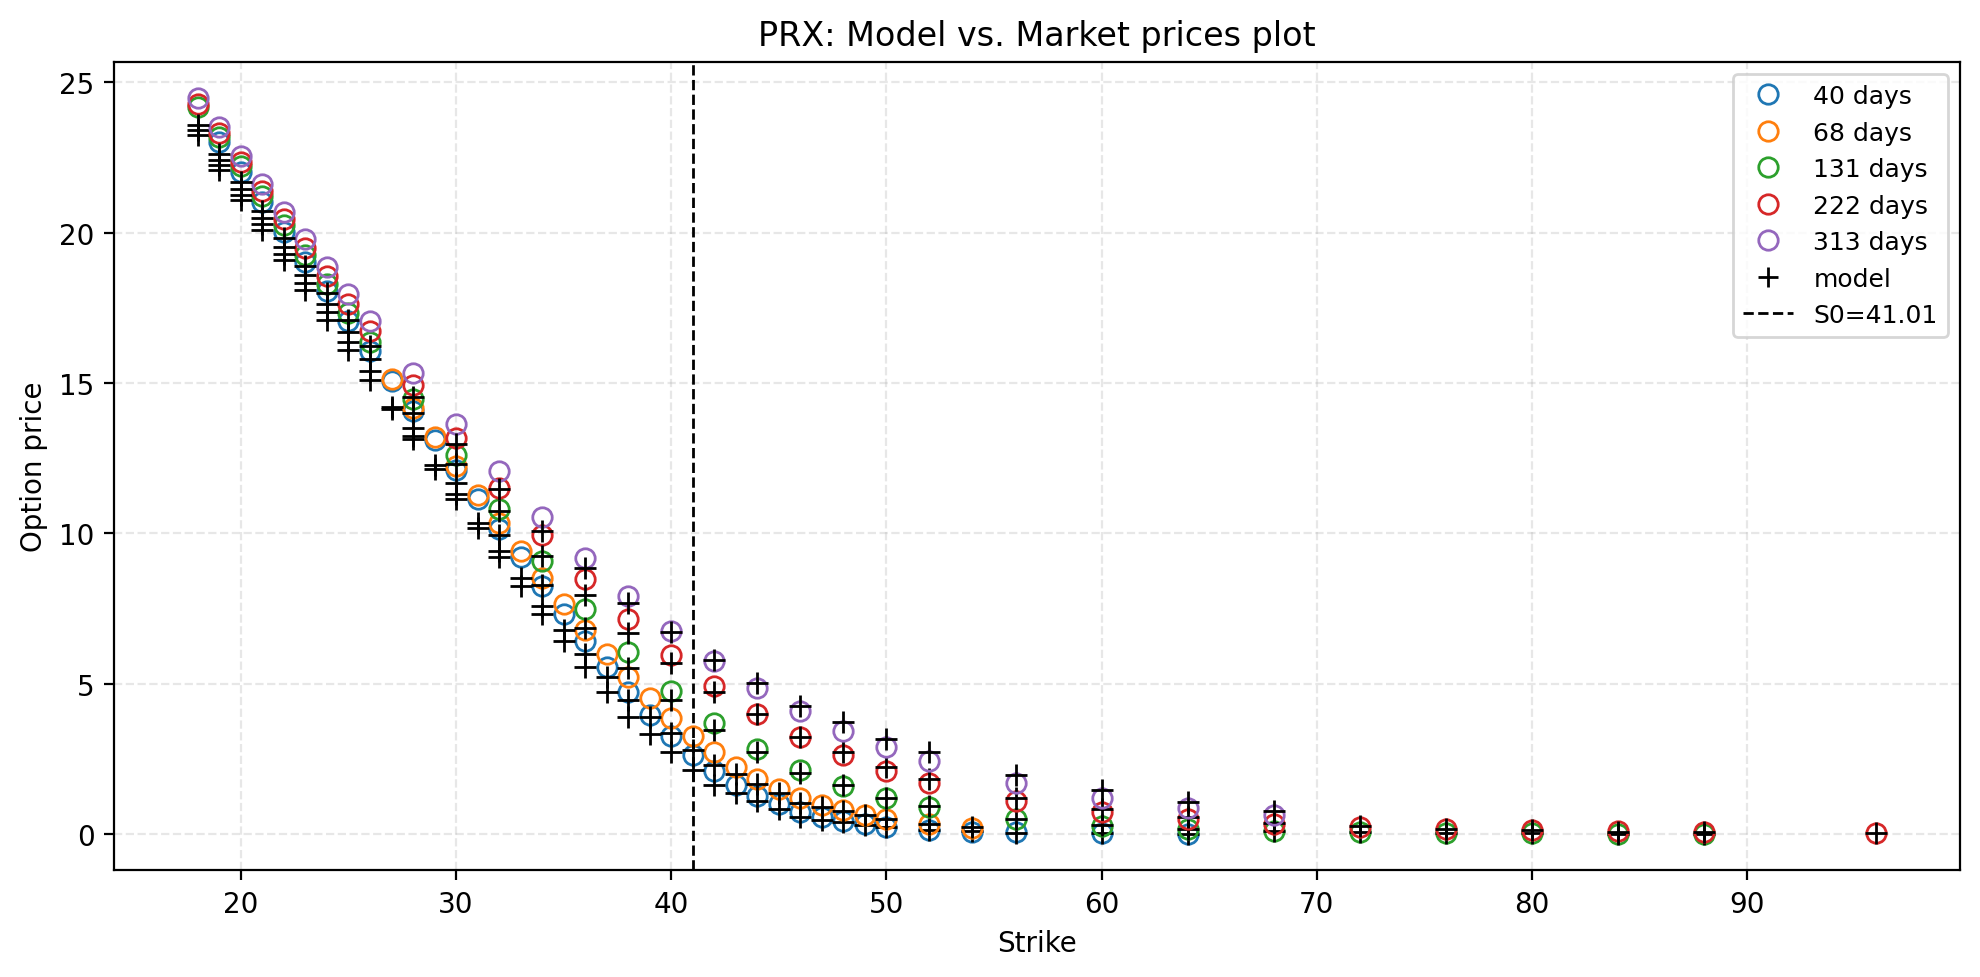

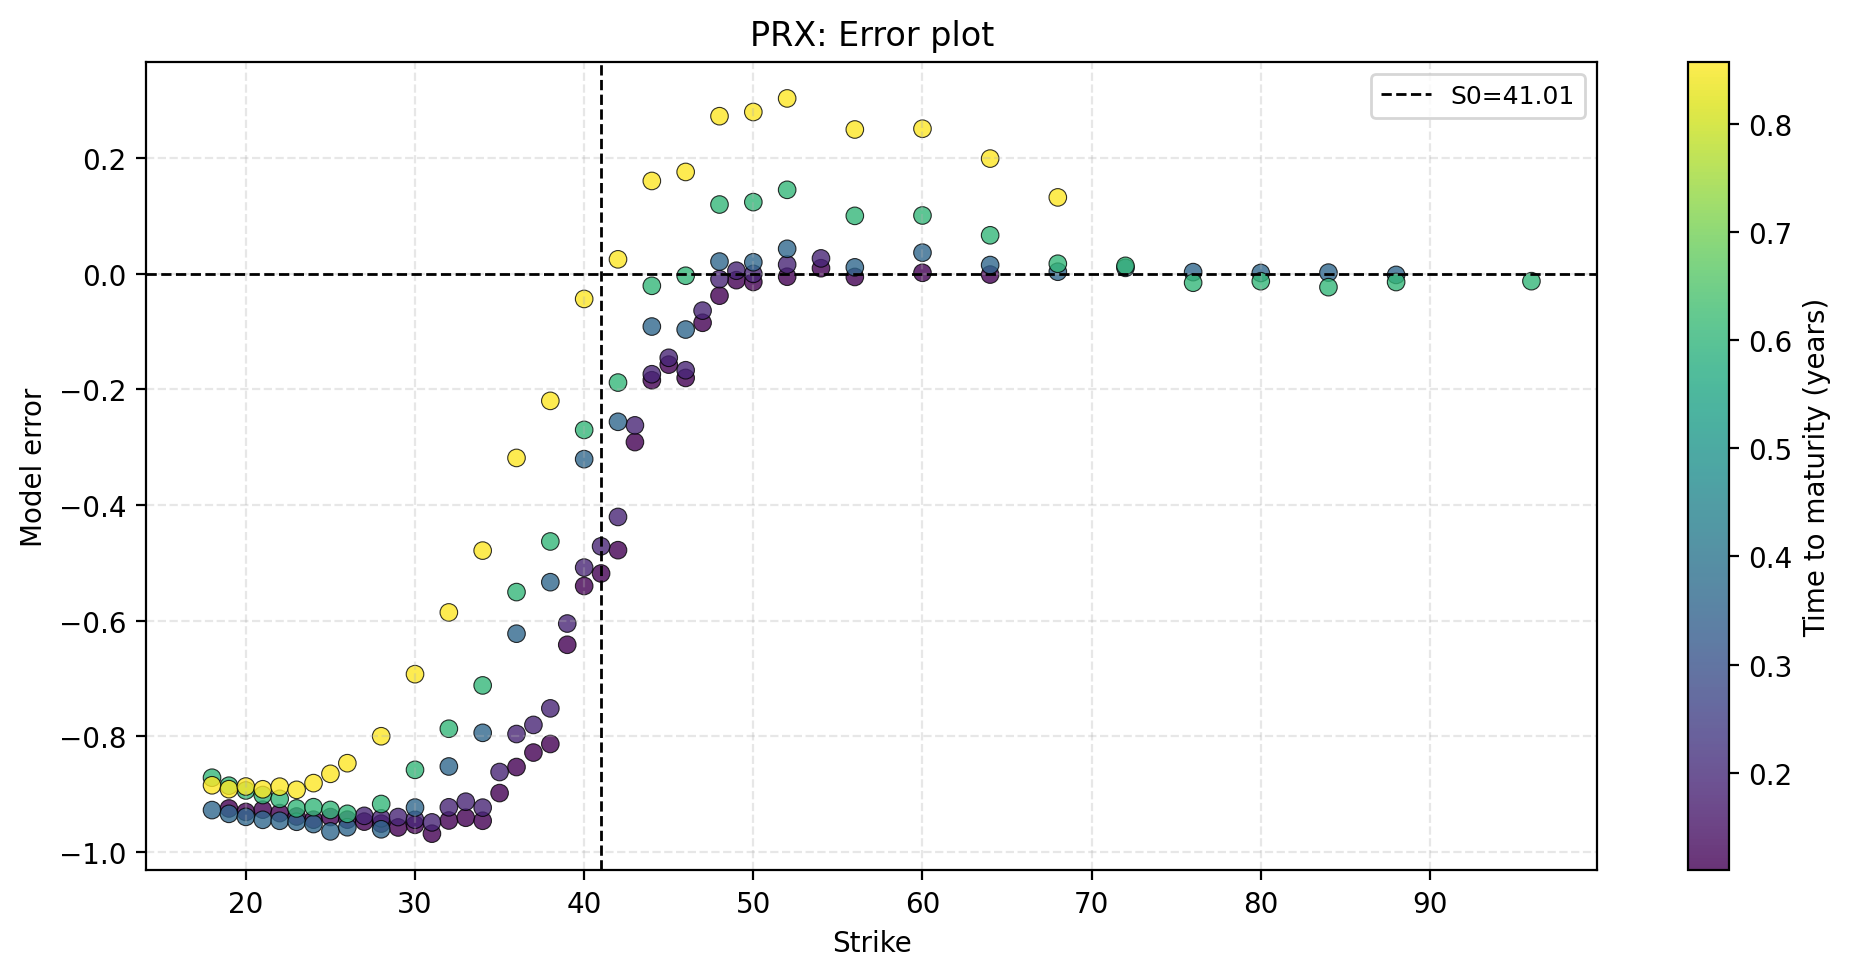

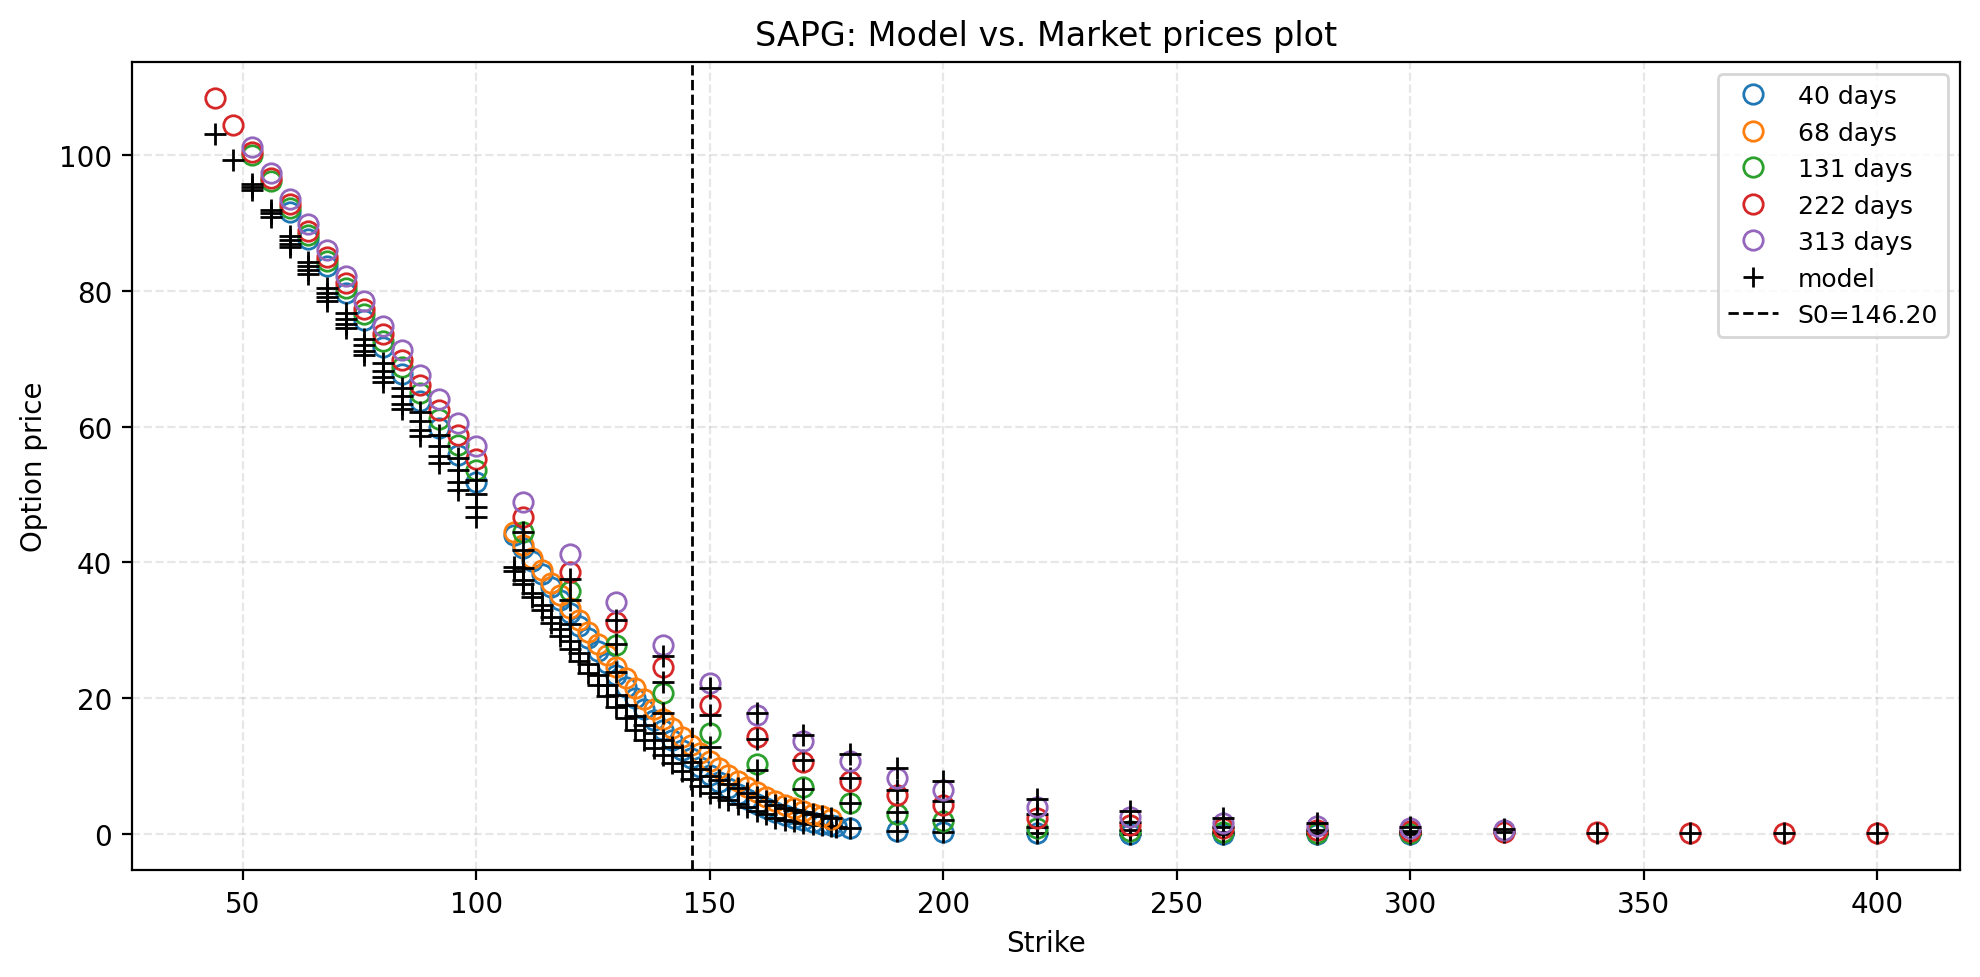

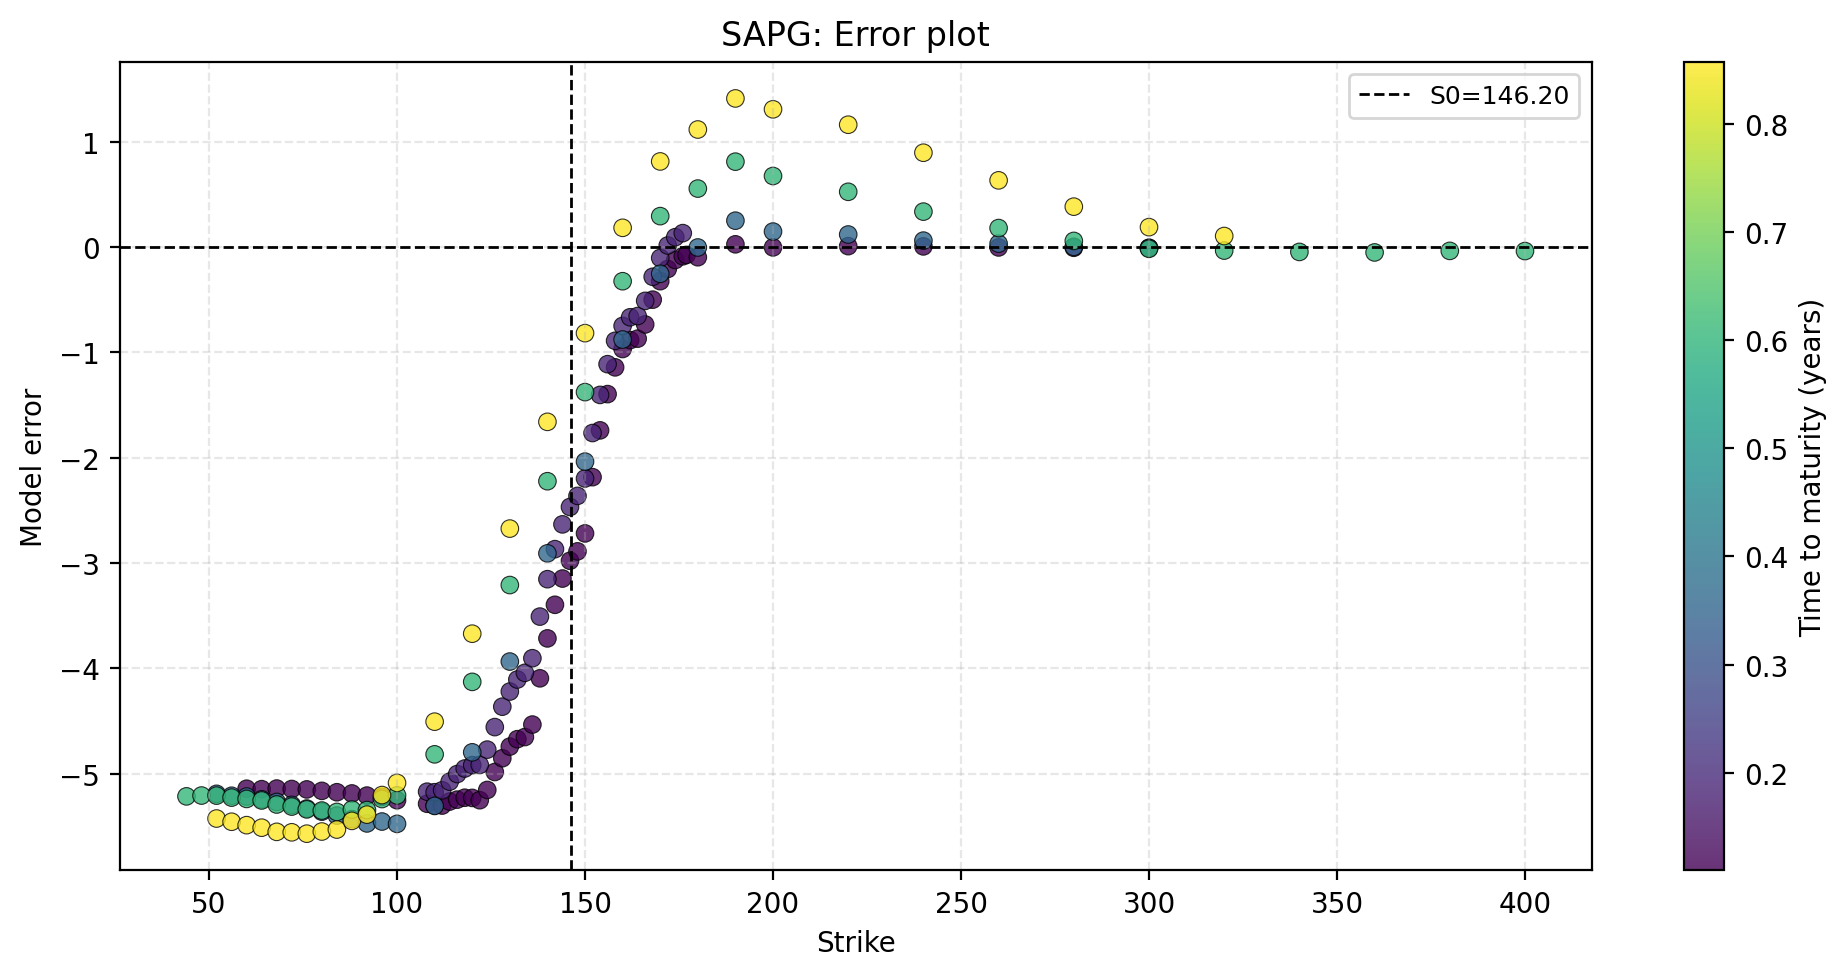

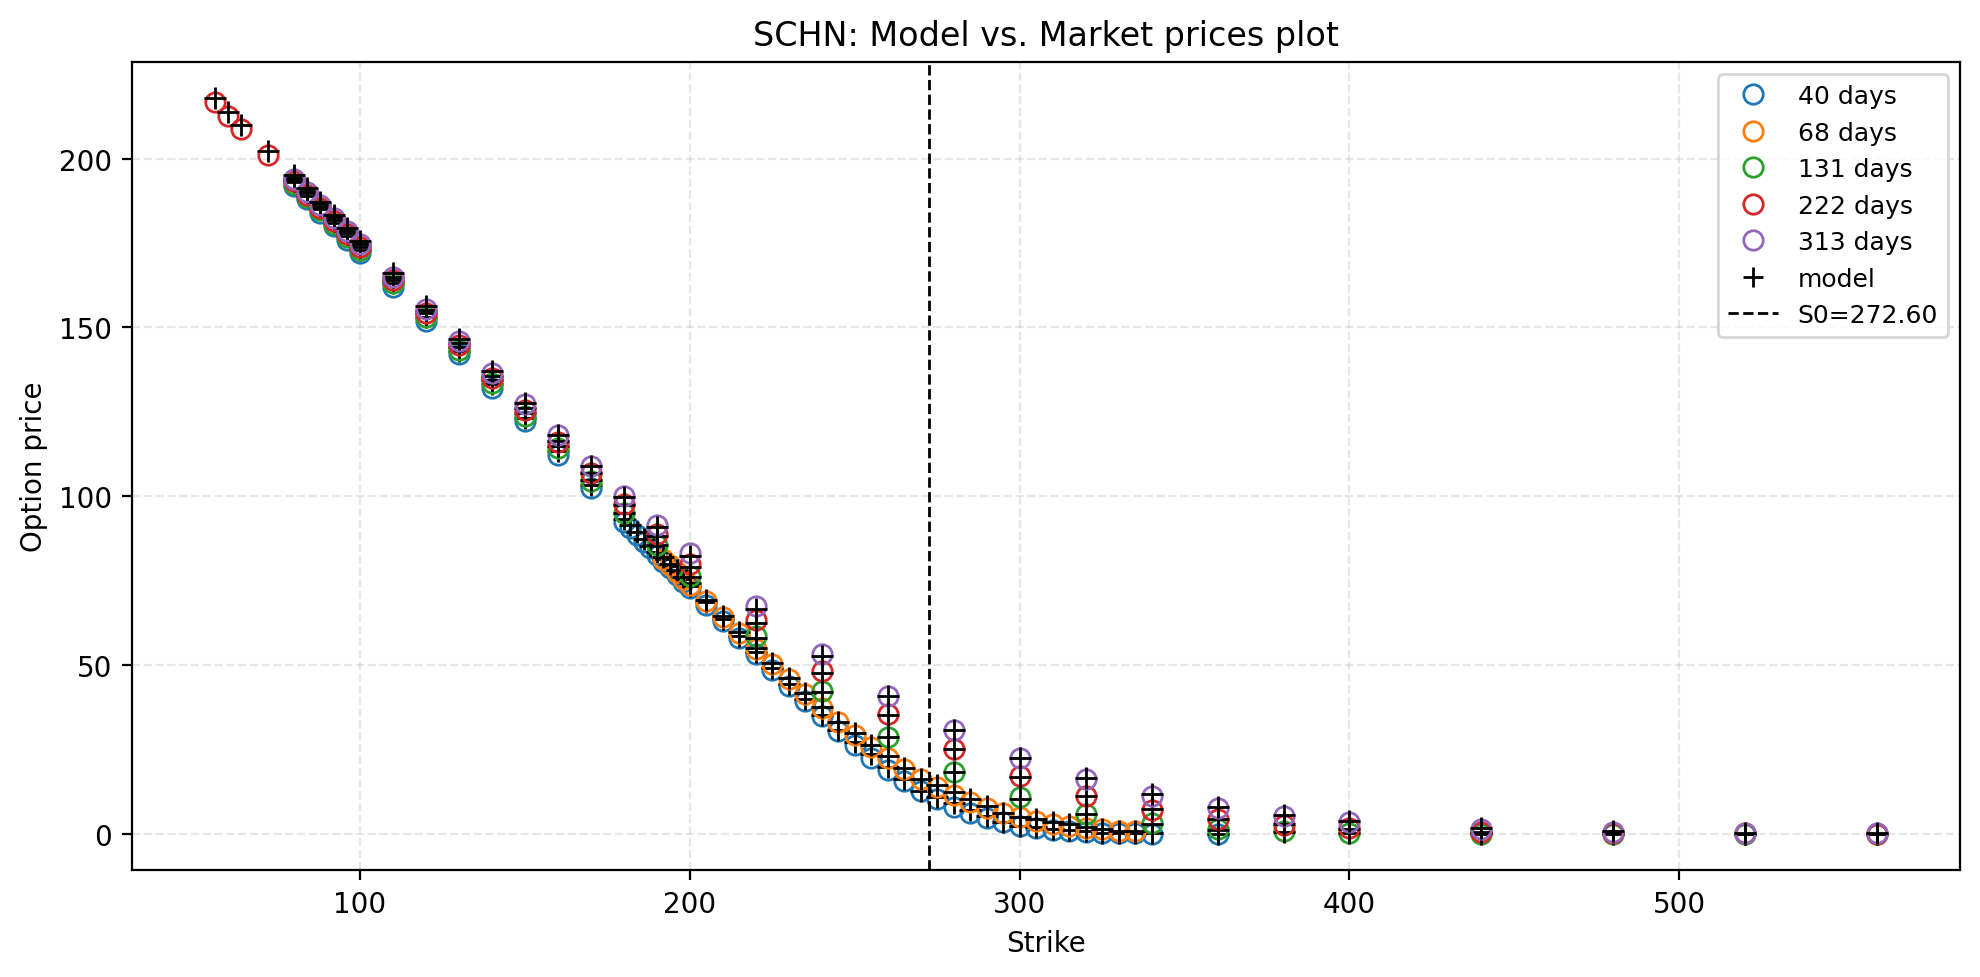

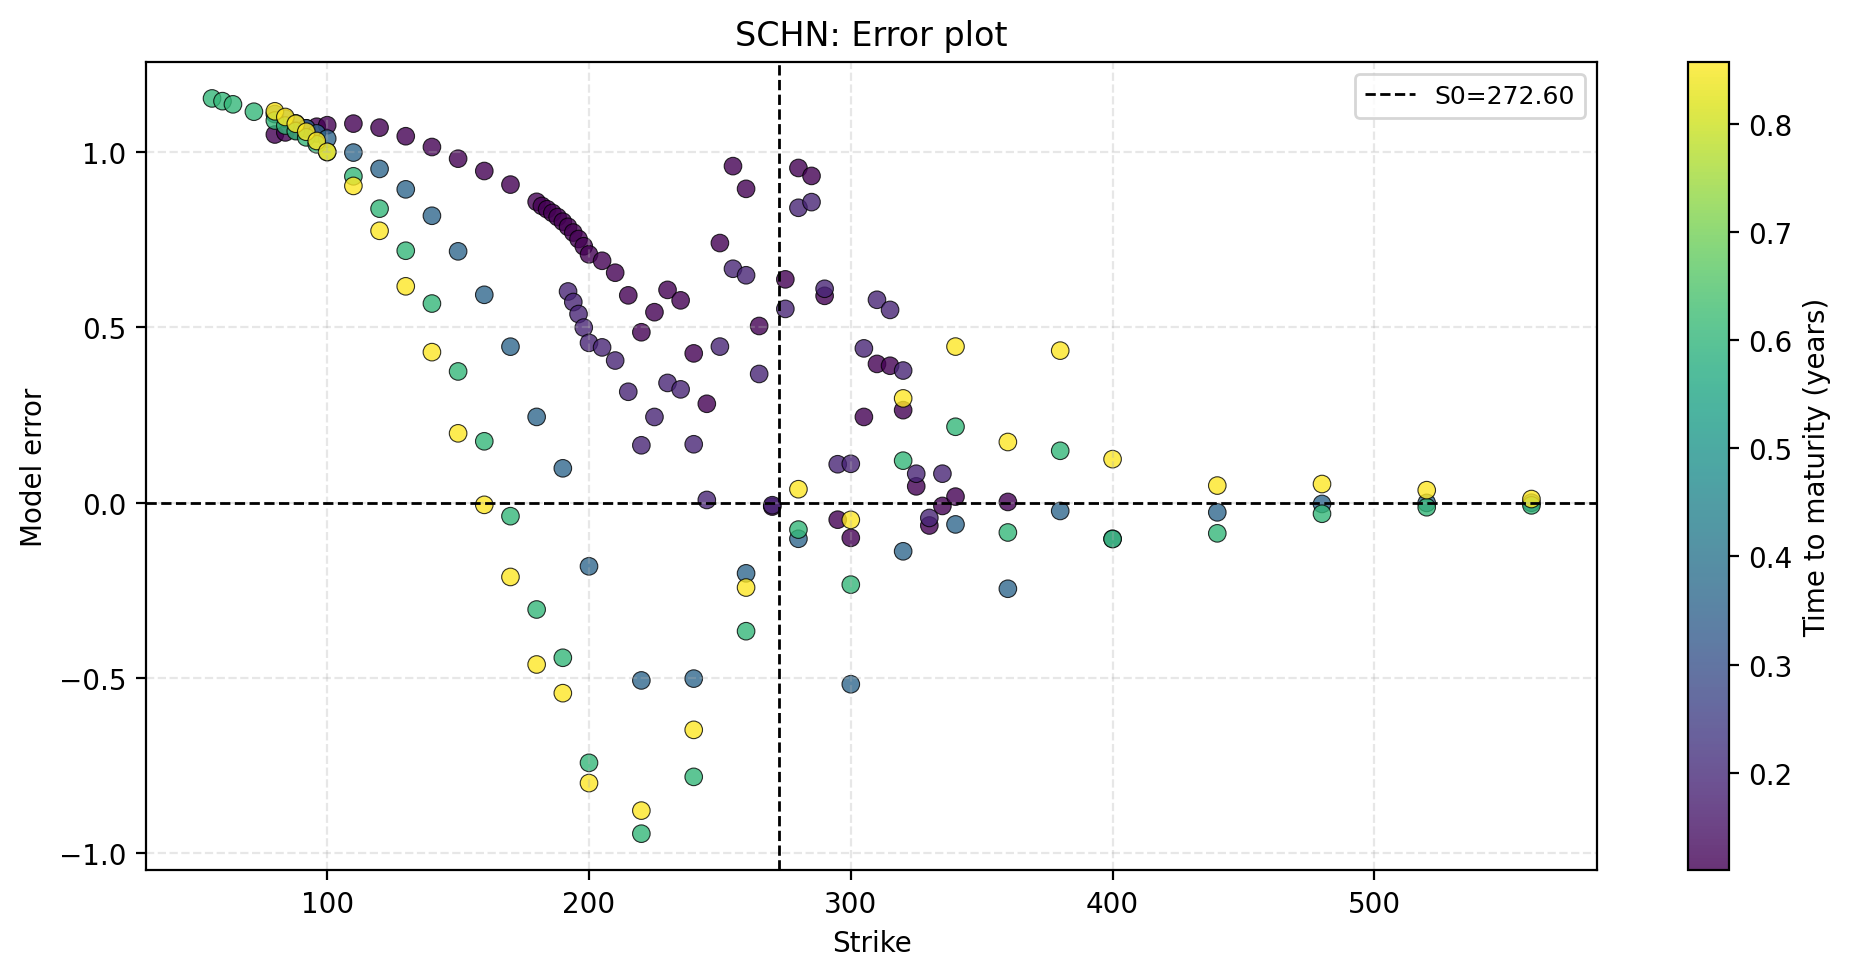

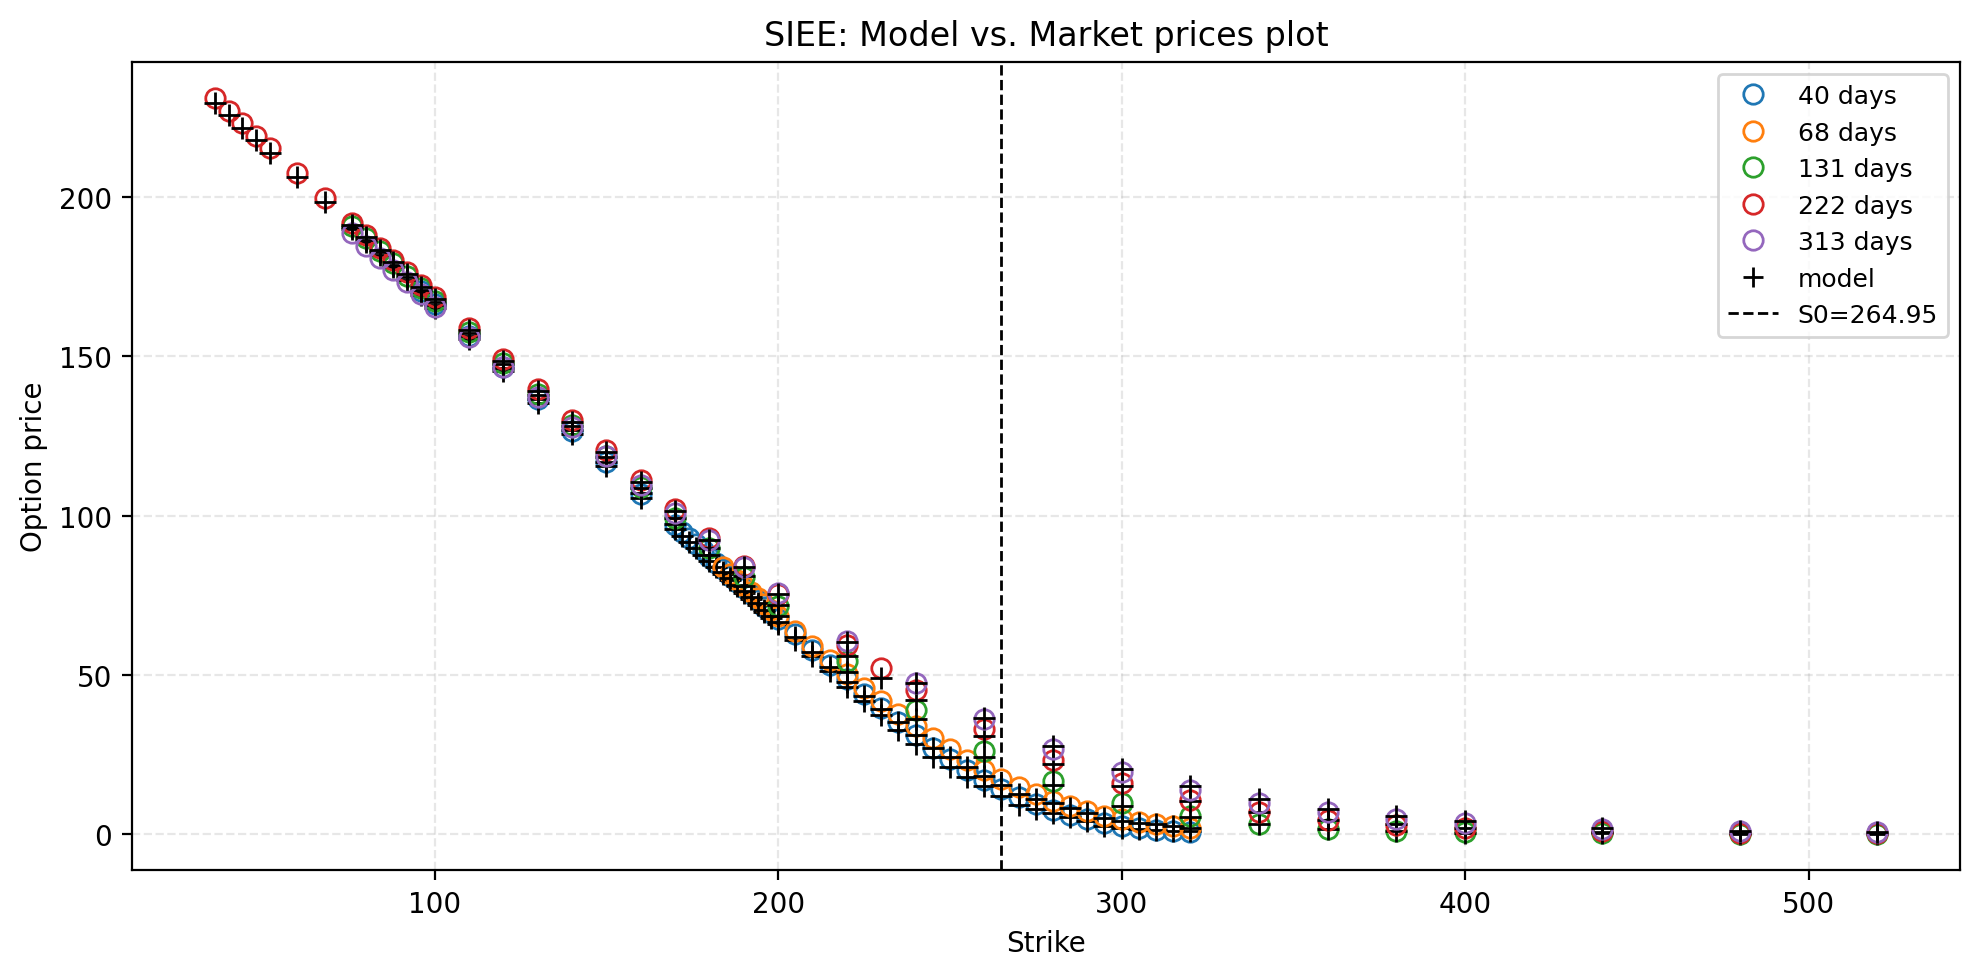

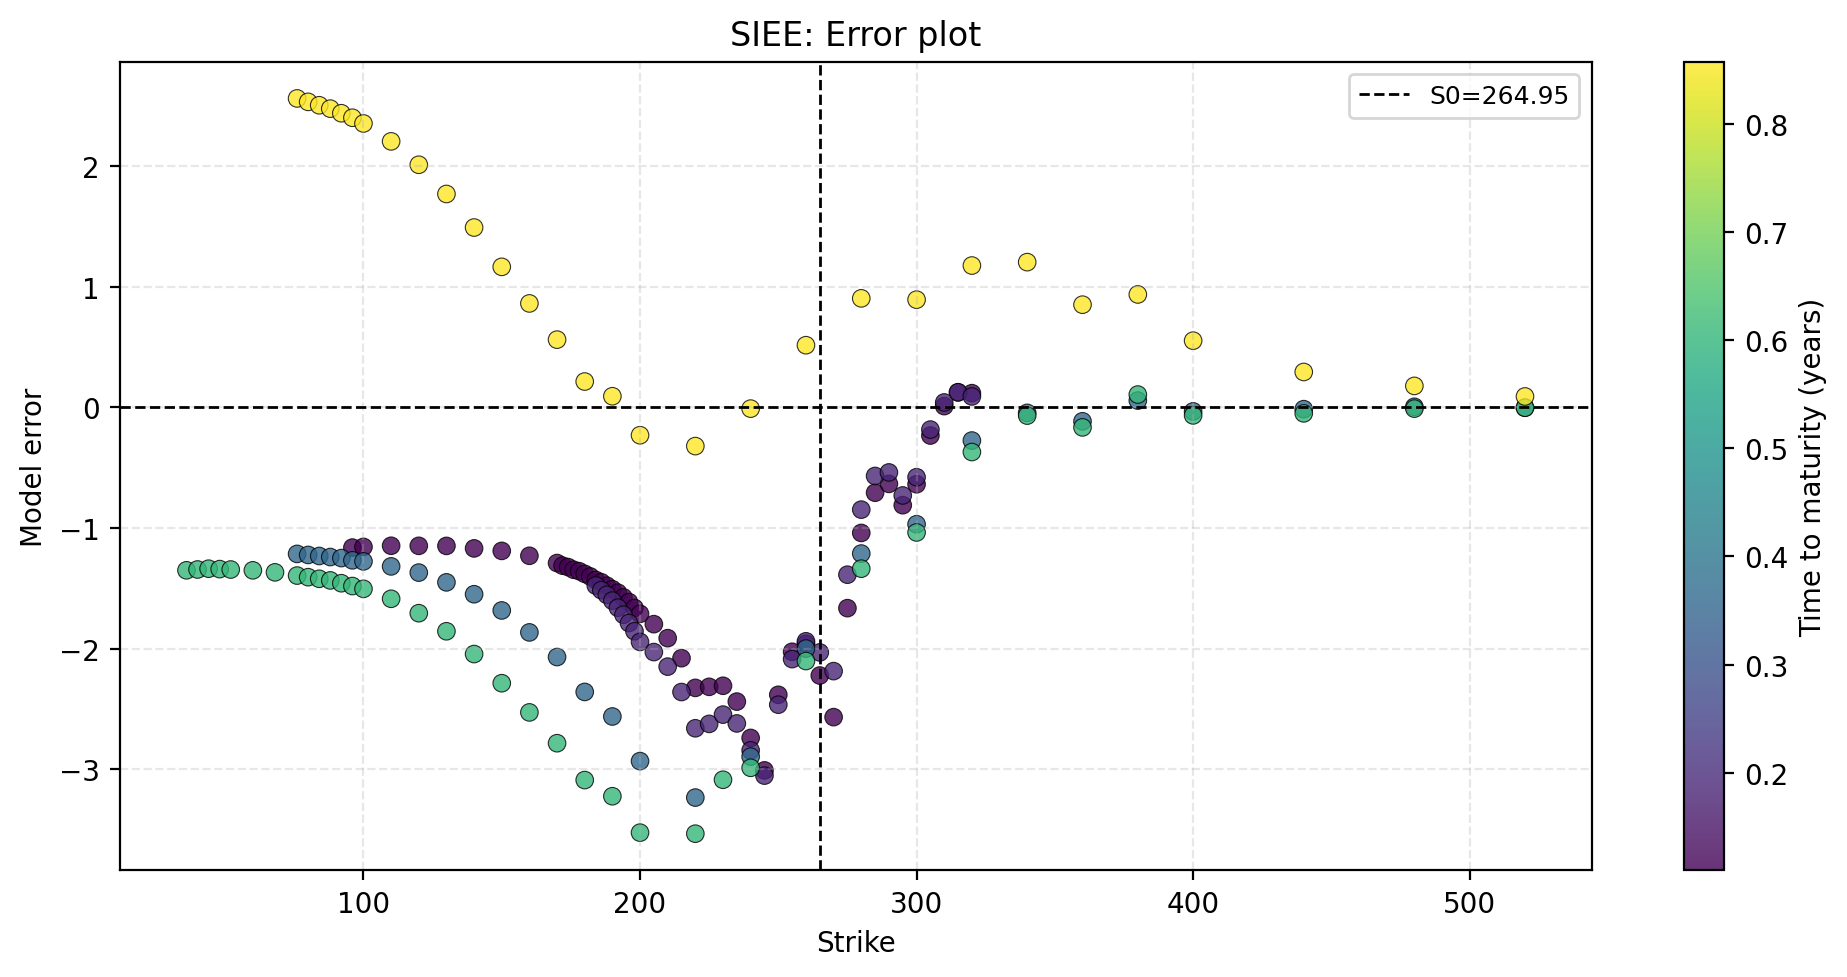

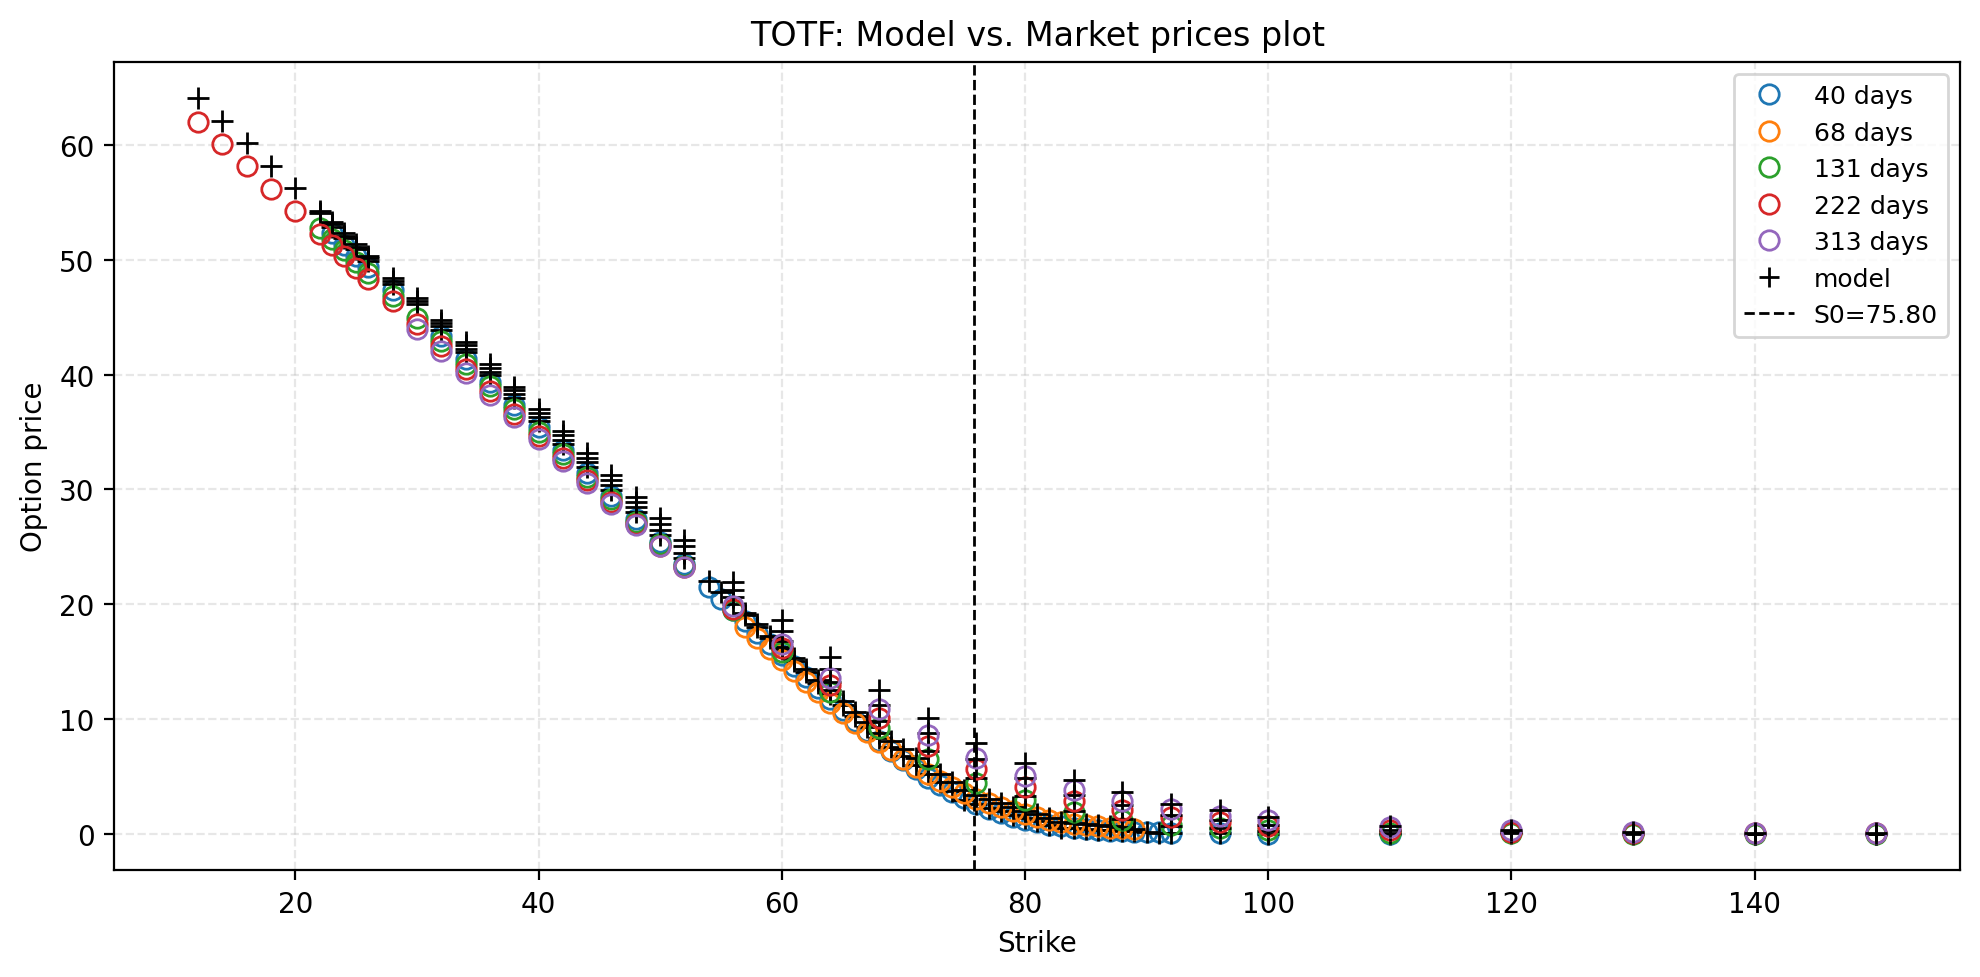

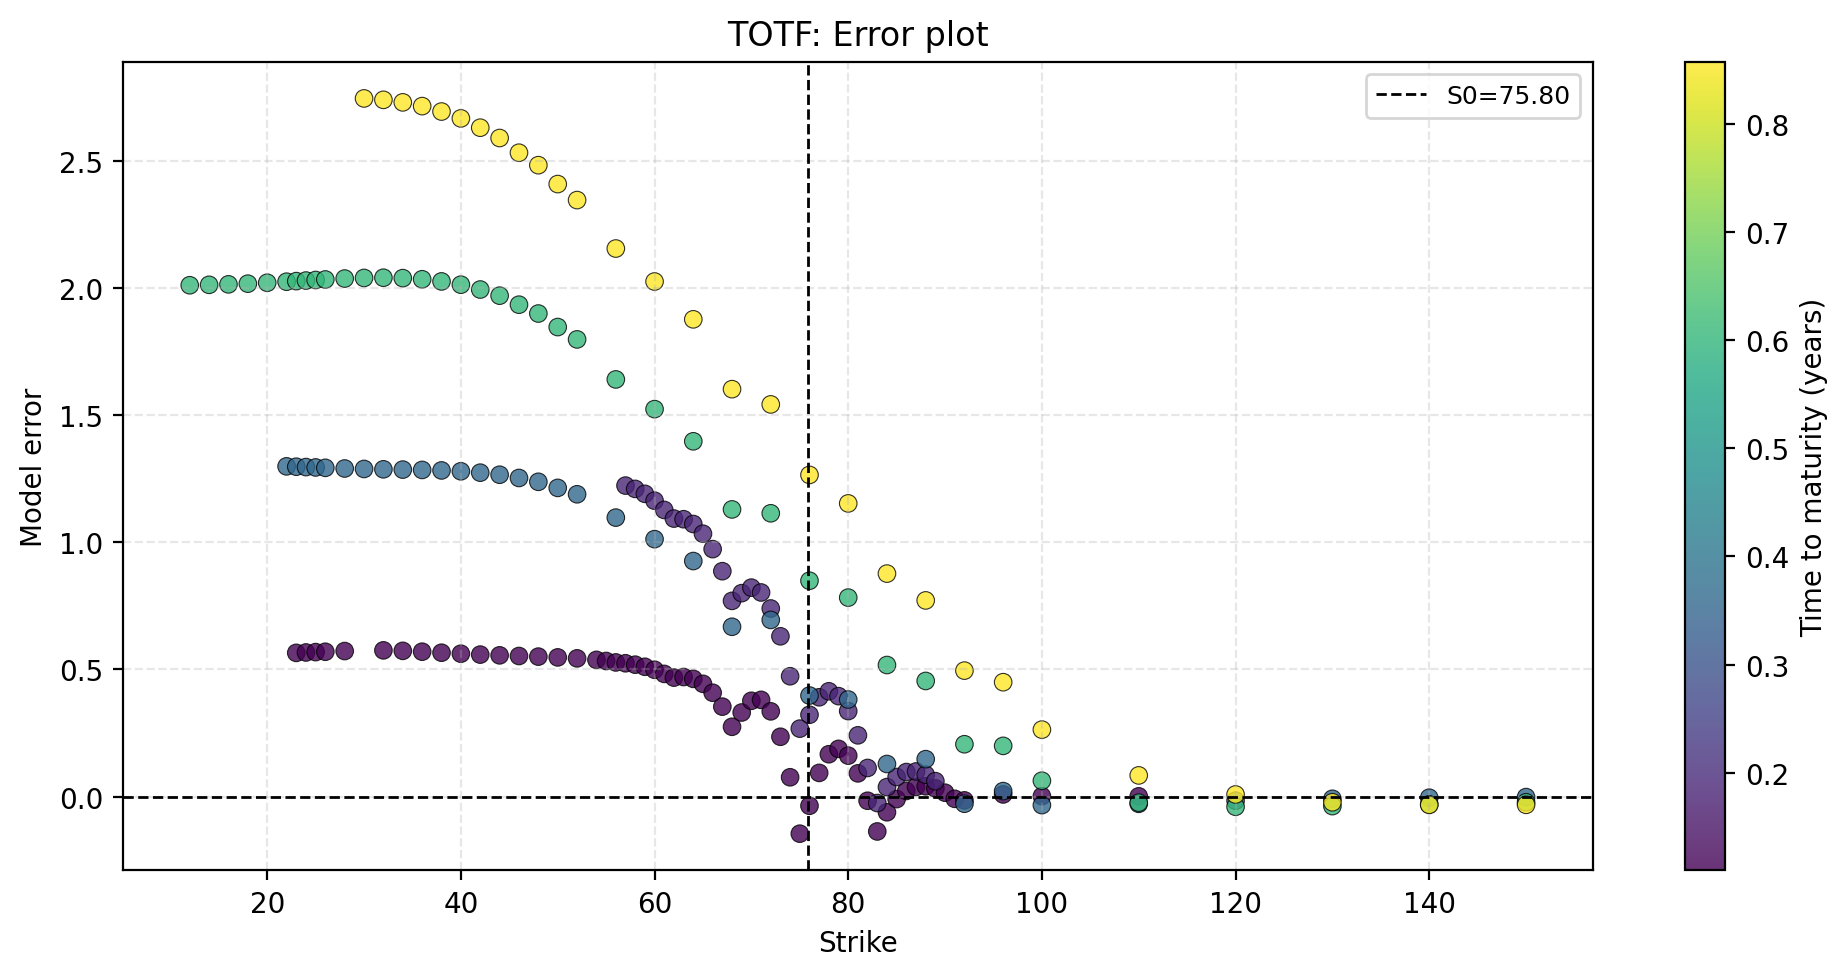

In [11]:
def plot_strike_slices(df, S0, price_col='FFT_price', plot_title='FFT calibration'):
    ttms = np.sort(df['time_to_maturity_years'].dropna().unique())
    ttm_days = (ttms * 365).astype(int)

    cmap = plt.get_cmap('tab10')
    fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

    for i, (tau, tau_days) in enumerate(zip(ttms, ttm_days)):
        sub = df[np.isclose(df['time_to_maturity_years'], tau, atol=1e-10, rtol=0.0)].sort_values('strike')
        color = cmap(i % 10)

        ax.plot(sub['strike'], sub['price'], marker='o', linestyle='none', markersize=7, markerfacecolor='none', markeredgecolor=color, label=f'{tau_days} days')
        ax.plot(sub['strike'], sub[price_col], marker='+', linestyle='none', markersize=8, color='k', label='_nolegend_')

    ax.plot([], [], marker='+', linestyle='none', color='k', markersize=7, label='model')
    ax.axvline(x=S0, linestyle='--', linewidth=1, color='k', label=f'S0={S0:.2f}')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Option price')
    ax.set_title(plot_title)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_residuals_vs_strike(df, S0, error_col='FFT_error', plot_title='FFT residuals'):
    fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
    sc = ax.scatter(df['strike'], df[error_col], c=df['time_to_maturity_years'], s=40, alpha=0.8, marker='o', edgecolors='k', linewidths=0.4)

    ax.axhline(0.0, color='k', linestyle='--', lw=1)
    ax.axvline(x=S0, linestyle='--', linewidth=1, color='k', label=f'S0={S0:.2f}')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Model error')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_title(plot_title)
    ax.legend(loc='best', fontsize=9)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Time to maturity (years)')
    fig.tight_layout()
    plt.show()


PLOT_RESULTS = True

if PLOT_RESULTS:
    for i, ticker in enumerate(tickers):
        plot_strike_slices(dfs[i], stock_prices[i], plot_title=f'{ticker}: Model vs. Market prices plot')
        plot_residuals_vs_strike(dfs[i], stock_prices[i], plot_title=f'{ticker}: Error plot')


## 3. Computing correlation and drift terms using stocks data

In [12]:
stocks_data_paths = {
    'ASML': './Stock Data/ASML.AS.xlsx',
    'HRMS': './Stock Data/HRMS.PA.xlsx',
    'ITX': './Stock Data/ITX.MC.xlsx',
    'LVMH': './Stock Data/LVMH.PA.xlsx',
    'OREP': './Stock Data/OREP.PA.xlsx',
    'PRX': './Stock Data/PRX.AS.xlsx',
    'SAPG': './Stock Data/SAPG.DE.xlsx',
    'SCHN': './Stock Data/SCHN.PA.xlsx',
    'SIEE': './Stock Data/SIEGn.DE.xlsx',
    'TOTF': './Stock Data/TTEF.PA.xlsx'
    }

In [13]:
dfs_read = []

for key, value in stocks_data_paths.items():
    df_read = pd.read_excel(value)
    df_read = df_read.rename(columns={'OFF_CLOSE': key})
    df_read['Date'] = pd.to_datetime(df_read['Date'])
    df_read = df_read[['Date', key]]
    dfs_read.append(df_read.set_index('Date').sort_index())

stocks_df = pd.concat(dfs_read, axis=1, join='outer')
stocks_df = stocks_df.sort_index().reset_index()
stocks_df.dropna(inplace=True)
stocks_df.head(10)

,Date,ASML,HRMS,ITX,LVMH,OREP,PRX,SAPG,SCHN,SIEE,TOTF
0,2025-05-12,666.9,2539.0,47.55,530.50,394.55,45.715,262.50,219.679932,221.75,53.07
1,2025-05-13,683.7,2596.0,48.43,536.90,385.15,45.600,262.35,220.000000,225.15,53.41
2,2025-05-14,686.6,2576.0,47.76,525.20,372.60,46.855,258.00,220.150000,224.05,53.11
3,2025-05-15,682.2,2567.0,48.20,507.30,376.90,46.220,263.20,220.650000,221.85,52.86
4,2025-05-16,668.4,2584.0,49.03,503.90,373.85,46.130,266.25,219.150000,219.95,53.23
5,2025-05-19,662.4,2559.0,48.50,498.60,378.55,46.080,265.45,218.650000,221.80,52.88
6,2025-05-20,660.0,2550.0,48.45,504.90,381.05,45.650,265.10,221.550000,222.25,53.01
7,2025-05-21,664.7,2496.0,48.57,493.65,385.45,46.285,265.80,219.650000,221.00,52.32
8,2025-05-22,656.8,2437.0,48.23,485.10,379.75,46.030,265.50,221.100000,217.10,51.50
9,2025-05-23,642.6,2373.0,47.07,479.00,372.95,45.135,260.55,217.150000,212.30,50.97


In [14]:
stocks_df.rename(columns={'ROPC': 'ROG', 'UBSG': 'UBSN'}, inplace=True)

In [15]:
stocks_df.tail()

,Date,ASML,HRMS,ITX,LVMH,OREP,PRX,SAPG,SCHN,SIEE,TOTF
249,2026-05-04,1187.4,1588.5,49.39,444.95,359.70,40.615,148.06,260.55,249.55,78.65
250,2026-05-05,1229.0,1588.0,50.44,450.95,361.35,40.720,149.80,272.95,260.50,79.30
251,2026-05-06,1305.0,1671.5,52.44,474.00,373.40,41.880,149.32,282.70,268.30,76.75
252,2026-05-07,1300.0,1702.0,52.68,478.30,367.00,41.960,151.38,275.20,266.20,75.27
253,2026-05-08,1319.4,1661.0,51.32,472.70,363.00,41.010,146.20,272.60,264.95,75.80


### 3.1 Correlation matrix

In [16]:
corr_matrix = stocks_df.corr(numeric_only=True)
corr_matrix

,ASML,HRMS,ITX,LVMH,OREP,PRX,SAPG,SCHN,SIEE,TOTF
ASML,1.000000,-0.698791,0.835180,0.210874,-0.199748,-0.382768,-0.921443,0.800939,0.510971,0.802017
HRMS,-0.698791,1.000000,-0.340282,0.153533,0.327692,0.358381,0.871123,-0.579325,-0.202929,-0.834231
ITX,0.835180,-0.340282,1.000000,0.473520,-0.016223,-0.246712,-0.673997,0.631206,0.562141,0.490900
LVMH,0.210874,0.153533,0.473520,1.000000,0.067115,0.618425,-0.045737,0.092281,0.484575,-0.268015
OREP,-0.199748,0.327692,-0.016223,0.067115,1.000000,0.122371,0.241847,-0.164016,0.342438,-0.366629
PRX,-0.382768,0.358381,-0.246712,0.618425,0.122371,1.000000,0.453402,-0.260994,0.235808,-0.703092
SAPG,-0.921443,0.871123,-0.673997,-0.045737,0.241847,0.453402,1.000000,-0.721844,-0.355621,-0.894056
SCHN,0.800939,-0.579325,0.631206,0.092281,-0.164016,-0.260994,-0.721844,1.000000,0.553580,0.662972
SIEE,0.510971,-0.202929,0.562141,0.484575,0.342438,0.235808,-0.355621,0.553580,1.000000,0.092893
TOTF,0.802017,-0.834231,0.490900,-0.268015,-0.366629,-0.703092,-0.894056,0.662972,0.092893,1.000000


### 3.2 Computing the drift

In [17]:
for ticker in tickers:
    log_return = np.log(stocks_df[ticker] / stocks_df[ticker].shift(1)).dropna()
    dt = 1/(len(log_return))

    mask = df_FFT['TKR'] == ticker
    sigma, theta, nu = df_FFT.loc[mask, ['sigma', 'theta', 'nu']].iloc[0].astype(float).to_numpy()
    
    omega = np.log(1 - theta*nu - 0.5*nu*sigma**2) / nu
    df_FFT.loc[mask, 'mu'] = log_return.mean()/dt - omega - theta

## 4. Saving the results

In [18]:
filepath_FFT_results = Path('./FFTResults/CalibrationResults/')
filepath_FFT_results.mkdir(parents=True, exist_ok=True)
output_file = filepath_FFT_results/'FFT_calibration_all_results.xlsx'

with pd.ExcelWriter(output_file) as writer:
    df_FFT.to_excel(writer, sheet_name='Parameter estimates', index=False)
    errors_df.to_excel(writer, sheet_name='Errors', index=False)

In [19]:
df_calibration = df_FFT[['TKR', 'S0', 'r', 'mu', 'C', 'G', 'M', 'sigma', 'theta', 'nu']]
df_calibration.to_excel(filepath_FFT_results/'FFT_estimates.xlsx', index=False)

corr_matrix.to_excel(filepath_FFT_results/'corr_matrix.xlsx', index=False)

In [20]:
df_calibration

,TKR,S0,r,mu,C,G,M,sigma,theta,nu
0,ASML,1319.40,0.036,0.762097,35.552707,21.111231,21.125317,0.399294,-0.001123,0.028127
1,HRMS,1661.00,0.036,-0.376535,80.875976,41.120758,41.144894,0.309198,-0.001154,0.012365
2,ITX,51.34,0.036,0.110297,47.401497,27.530204,83.049679,0.203628,-1.151039,0.021096
3,LVMH,472.70,0.036,-0.065748,10.000063,14.204227,14.224724,0.314619,-0.001014,0.099999
4,OREP,363.00,0.036,-0.049211,26.510965,21.871892,43.124724,0.237094,-0.597351,0.037720
5,PRX,41.01,0.036,-0.037783,19.877356,16.705247,16.823077,0.376110,-0.008334,0.050309
6,SAPG,146.20,0.036,-0.507405,27.527768,18.799312,18.829246,0.394378,-0.002328,0.036327
7,SCHN,272.60,0.036,0.260180,148.677592,40.634481,1223.445847,0.077339,-3.537379,0.006726
8,SIEE,264.95,0.036,0.225190,105.697075,47.294426,47.358739,0.307214,-0.003035,0.009461
9,TOTF,75.80,0.036,0.386581,19.011973,25.127325,25.160588,0.245242,-0.001000,0.052598
